<a href="https://colab.research.google.com/github/MGS30895/MOF-Synthesis-Data-Analysis/blob/main/TopModels_DeepDive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep-Dive: Best Models per Dataset × Target
## MOF Synthesis — NU-1000 (BPh) / NU-901 (BA)

This notebook reproduces **exactly** the best models identified in the progression table, then goes deep on each one.

### Best models (from main notebook + Run10_RawTargets)

| Dataset | Target | Run | Model | LOO-R² log | R² original |
|---|---|---|---|---|---|
| BA | particle_size_nm | Run_8 | KernelRidge_Laplacian | +0.692 | +0.674 |
| BA | pxrd_ratio | Run_7 | ElasticNet | +0.631 | +0.540 |
| BPh | particle_size_nm | Run_10 | SVR | +0.663 | +0.513 |
| BPh | pxrd_ratio | Run_2LOO | SVR | +0.424 | +0.299 |
| Merged | particle_size_nm | Run_8 | SVR | +0.741 | +0.612 |
| Merged | pxrd_ratio | Run_10 | KNN | +0.703 | +0.630 |

Plus the **Run10_RawTargets** results (6 raw features, raw-space training).

### Key notes on reproduction
- **Run_8** uses `FEATURE_COLS_R5 + ["regime_score"]` (23 features), `select_features` (Spearman only), `RobustScaler`
- **Run_7** uses `FEATURE_COLS_R5 + ["is_likely_large"]` (23 features), `select_features` (Spearman only), `RobustScaler`
- **Run_10** uses `FEATURE_COLS_R5 + ["regime_score"]` (23 features), `select_features_union` (Spearman OR MI, MI_THRESHOLD=0.10), `RobustScaler`
- **Run_2LOO** uses `FEATURE_COLS_R2` (12 features), `select_features` (Spearman threshold=0.3 uniform), `RobustScaler`
- **Run10_RawTargets** uses 6 raw features only, no feature selection, trains directly on raw targets, `StandardScaler`


## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import (LeaveOneOut, KFold, GridSearchCV,
                                      RandomizedSearchCV, cross_val_predict)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   BayesianRidge, HuberRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor,
                               IsolationForest)
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import loguniform
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
PALETTE = {'BPh': '#1a7abf', 'BA': '#e07b39', 'Merged': '#8fbc5a'}
print("Libraries loaded.")


Libraries loaded.


## 2. Constants & Helper Functions

In [ ]:
BPH_CSV = "/content/csv_data_NU-1000-901-Bph.csv"
BA_CSV  = "/content/csv_data_NU-1000-901-BA.csv"

ZR6_MASS_MG  = 69.0;  ZR6_MW = 1388.4;  ZR6_MMOL = ZR6_MASS_MG / ZR6_MW
MW_LINKER    = 682.68;  MW_BIPHCOOH = 198.22;  MW_BA = 122.12
MW_TFA       = 114.02;  DENSITY_TFA = 1.489
PKA_BA = 4.20;  PKA_BPH = 4.18;  PKA_TFA = 0.52;  ZR6_COORD = 8
SIZE_SMALL_MAX = 300;  SIZE_MEDIUM_MAX = 1000

RANDOM_STATE = 42;  N_SPLITS = 5;  N_ITER = 50;  N_JOBS = -1

def mass_to_eq(mass, mw_g_per_mol, unit="g"):
    mass = np.asarray(mass, dtype=float)
    mass_g = mass / 1000.0 if unit == "mg" else mass
    return (mass_g / mw_g_per_mol * 1000.0) / ZR6_MMOL

def vol_ul_to_eq(vol_ul, mw_g_per_mol, density_g_per_ml):
    vol_ul = np.asarray(vol_ul, dtype=float)
    return (vol_ul * 1e-3 * density_g_per_ml / mw_g_per_mol * 1000.0) / ZR6_MMOL

def assign_phase(ratio):
    ratio = np.asarray(ratio, dtype=float)
    return np.where(ratio >= 2, "NU-1000", np.where(ratio <= 0.01, "NU-901", "Mixed"))

def assign_size_regime(size_nm):
    size_nm = np.asarray(size_nm, dtype=float)
    return np.where(size_nm < SIZE_SMALL_MAX, "Small",
           np.where(size_nm < SIZE_MEDIUM_MAX, "Medium", "Large"))

print(f"ZR6_MMOL = {ZR6_MMOL:.5f} mmol")


ZR6_MMOL = 0.04970 mmol


## 3. Data Loading & Preprocessing

*Exact column maps and unit conversions from source notebooks.*

In [ ]:
BPH_RENAME = {
    "mass linker": "mass_linker_mg", "mass Bph": "mass_modulator_g",
    "volume co-modulator": "vol_TFA_uL", "volume linker solution": "vol_linker_mL",
    "volume Zr6-oxocluster solution": "vol_node_mL", "temperature": "T_reaction",
    "time": "time_h", "success": "success",
    "reflection ratio 2.6:5.2": "pxrd_ratio", "particle size": "particle_size_nm",
    "particle size distribution": "particle_size_stdv_pct",
}
BA_RENAME = {
    "mass linker": "mass_linker_mg", "mass BA": "mass_modulator_g",
    "volume co-modulator": "vol_TFA_uL", "volume linker solution": "vol_linker_mL",
    "volume Zr6-oxocluster solution": "vol_node_mL", "temperature": "T_reaction",
    "time": "time_h", "Hot Addition": "T_addition", "success": "success",
    "reflection ratio 2.6:5.2": "pxrd_ratio", "particle size": "particle_size_nm",
    "particle size distribution": "particle_size_stdv_pct",
}

bph_raw = pd.read_csv(BPH_CSV); bph_raw.columns = bph_raw.columns.str.strip()
ba_raw  = pd.read_csv(BA_CSV);  ba_raw.columns  = ba_raw.columns.str.strip()
bph = bph_raw.rename(columns=BPH_RENAME).copy()
ba  = ba_raw.rename(columns=BA_RENAME).copy()

bph["modulator_type"] = "BiPhCOOH"
ba["modulator_type"]  = "BA"
# BPh has no Hot Addition column → T_addition = 25.0 for all rows (per SI)
bph["T_addition"] = 25.0

bph = bph[bph["success"] == 1].drop(columns=["success"]).reset_index(drop=True)
ba  = ba[ba["success"]   == 1].drop(columns=["success"]).reset_index(drop=True)
print(f"BPh: {len(bph)} rows | BA: {len(ba)} rows")


BPh: 83 rows | BA: 63 rows


In [ ]:
# ── Unit conversions + all engineered features ────────────────────────────────
for df, name, mod_mw in [(bph, "BPh", MW_BIPHCOOH), (ba, "BA", MW_BA)]:
    df["eq_modulator"] = mass_to_eq(df["mass_modulator_g"], mod_mw, unit="g")
    df["eq_linker"]    = mass_to_eq(df["mass_linker_mg"], MW_LINKER, unit="mg")
    # eq_TFA: µL → equivalents → log1p  (exact formula from source notebooks)
    df["eq_TFA"]       = np.log1p(vol_ul_to_eq(df["vol_TFA_uL"], MW_TFA, DENSITY_TFA))
    # V_total_mL = vol_linker_mL + vol_node_mL  (TFA µL not included)
    df["V_total_mL"]   = df["vol_linker_mL"] + df["vol_node_mL"]
    df["addition_hot"] = (df["T_addition"] >= 100).astype(int)
    # Engineered features (Run 2 set)
    df["modulator_concentration"] = np.log1p(df["eq_modulator"] / df["V_total_mL"])
    df["thermal_dose"]            = np.log10(df["T_reaction"] * df["time_h"])
    df["tfa_ratio"]               = np.log1p(df["eq_TFA"] / df["eq_modulator"])
    df["modulation_effect"]       = np.log1p(df["eq_TFA"] * df["eq_modulator"])
    df["linker_conc"]             = df["eq_linker"] / df["V_total_mL"]
    df["mod_x_T"]                 = np.log10(df["eq_modulator"] * df["T_reaction"])
    df["TFA_present"]             = (df["eq_TFA"] > 0).astype(int)
    # Run 4 features
    df["mod_to_linker"]           = df["eq_modulator"] / df["eq_linker"]
    df["TFA_to_linker"]           = df["eq_TFA"] / df["eq_linker"]
    df["total_cap_to_linker"]     = (df["eq_modulator"] + df["eq_TFA"]) / df["eq_linker"]
    df["supersaturation"]         = df["linker_conc"] * df["modulator_concentration"]
    df["dilution"]                = df["V_total_mL"] / df["eq_linker"]
    df["T_gradient"]              = df["T_reaction"] - df["T_addition"]
    print(f"{name}: V_total_mL {df['V_total_mL'].min():.2f}–{df['V_total_mL'].max():.2f} mL")

# ── Run 5 chemistry-informed features ─────────────────────────────────────────
N_ZR6_MMOL = ZR6_MMOL
for df, pka_mod in [(bph, PKA_BPH), (ba, PKA_BA)]:
    df["linker_conc_mM"]     = (df["eq_linker"] * N_ZR6_MMOL) / df["V_total_mL"]
    df["Zr6_conc_mM"]        = N_ZR6_MMOL / df["V_total_mL"]
    df["acidity_score"]      = df["eq_modulator"]*(14-pka_mod) + df["eq_TFA"]*(14-PKA_TFA)
    df["TFA_acidity_boost"]  = df["eq_TFA"]*(pka_mod-PKA_TFA) / (df["eq_modulator"]+1e-9)
    df["node_linker_coverage"] = (4*df["eq_linker"]) / ZR6_COORD
    df["mod_site_competition"] = ((df["eq_modulator"]+df["eq_TFA"])
                                   / (4*df["eq_linker"]+df["eq_modulator"]+df["eq_TFA"]+1e-9))
    df["delta_T"]            = df["T_reaction"] - df["T_addition"]
    df["T_x_TFA"]            = df["T_reaction"] * df["eq_TFA"]

# ── Log targets + regime labels ────────────────────────────────────────────────
for df in [bph, ba]:
    df["log10_particle_size"] = np.log10(df["particle_size_nm"].clip(lower=1e-6))
    df["log1p_pxrd_ratio"]    = np.log1p(df["pxrd_ratio"].clip(lower=1e-6))
    df["phase"]               = assign_phase(df["pxrd_ratio"])
    df["size_regime"]         = assign_size_regime(df["particle_size_nm"])
    df["TFA_was_added"]       = (df["vol_TFA_uL"] > 0).astype(int)

print("All features computed.")


BPh: V_total_mL 7.90–16.00 mL
BA: V_total_mL 8.00–16.00 mL
All features computed.


## 4. Merged Dataset + modulator_dummy

In [ ]:
COMMON_COLS = [
    "modulator_type", "mass_linker_mg", "mass_modulator_g", "vol_TFA_uL",
    "vol_linker_mL", "vol_node_mL", "T_reaction", "time_h", "T_addition",
    "modulator_concentration", "thermal_dose", "modulation_effect", "tfa_ratio",
    "TFA_present", "linker_conc", "mod_x_T", "mod_to_linker", "TFA_to_linker",
    "total_cap_to_linker", "supersaturation", "dilution", "T_gradient",
    "eq_modulator", "eq_linker", "eq_TFA", "V_total_mL", "addition_hot",
    "TFA_was_added", "pxrd_ratio", "log1p_pxrd_ratio",
    "particle_size_nm", "particle_size_stdv_pct",
    "log10_particle_size", "phase", "size_regime",
    # Run 5 features
    "linker_conc_mM", "Zr6_conc_mM", "acidity_score", "TFA_acidity_boost",
    "node_linker_coverage", "mod_site_competition", "delta_T", "T_x_TFA",
]
bph_a = bph[[c for c in COMMON_COLS if c in bph.columns]].copy()
ba_a  = ba[[c  for c in COMMON_COLS if c in ba.columns]].copy()
merged = pd.concat([bph_a, ba_a], ignore_index=True)
# modulator_dummy: 1=BiPhCOOH, 0=BA
merged["modulator_dummy"] = (merged["modulator_type"] == "BiPhCOOH").astype(int)
print(f"Merged: {len(merged)} rows")


Merged: 146 rows


## 5. Regime Features

### is_likely_large (Run 7)
Binary, derived from input features only — no target leakage.
- BPh: `modulation_effect >= 6.320`
- BA: `mod_to_linker >= 199.221`

### regime_score (Run 8/10)
Continuous [0,1] — fraction of per-dataset input rules that fire.


In [ ]:
# ── is_likely_large (Run 7) ───────────────────────────────────────────────────
bph["is_likely_large"] = (bph["modulation_effect"] >= 6.320).astype(int)
ba["is_likely_large"]  = (ba["mod_to_linker"]       >= 199.221).astype(int)
merged["is_likely_large"] = np.where(
    merged["modulator_type"] == "BiPhCOOH",
    (merged["modulation_effect"] >= 6.320).astype(int),
    (merged["mod_to_linker"]     >= 199.221).astype(int)
)

for ds_name, df in [("BPh", bph), ("BA", ba)]:
    actual = (df["size_regime"] == "Large").astype(int)
    acc = (df["is_likely_large"] == actual).mean()
    print(f"{ds_name} is_likely_large accuracy: {acc:.1%}")

# ── regime_score (Run 8/10) ────────────────────────────────────────────────────
REGIME_RULES = {
    "BPh": [("modulation_effect", 6.320), ("T_x_TFA", None),
             ("mod_x_T", None), ("eq_TFA", None), ("acidity_score", None)],
    "BA":  [("mod_to_linker", 199.221), ("total_cap_to_linker", None),
             ("mod_site_competition", None), ("modulator_concentration", None),
             ("acidity_score", None)],
}

def find_threshold(df, feature, positive_class="Large"):
    vals = df[feature].dropna()
    thresholds = np.percentile(vals, np.arange(10, 91, 5))
    actual = (df["size_regime"] == positive_class).astype(int)
    best_t, best_acc = None, 0
    for t in thresholds:
        acc = ((df[feature] >= t).astype(int) == actual).mean()
        if acc > best_acc: best_acc, best_t = acc, t
    return best_t, best_acc

resolved_rules = {}
for ds_name, df in [("BPh", bph), ("BA", ba)]:
    resolved = []
    for feat, thresh in REGIME_RULES[ds_name]:
        if feat not in df.columns: continue
        if thresh is None: thresh, _ = find_threshold(df, feat)
        resolved.append((feat, thresh))
    resolved_rules[ds_name] = resolved
    scores = np.zeros(len(df))
    for feat, thresh in resolved:
        scores += (df[feat] >= thresh).astype(float)
    df["regime_score"] = scores / len(resolved)
    print(f"{ds_name} regime_score: {df['regime_score'].min():.2f}–{df['regime_score'].max():.2f}")

# Add regime_score to merged
scores_merged = np.zeros(len(merged))
for idx, row in merged.iterrows():
    ds = "BPh" if row["modulator_type"] == "BiPhCOOH" else "BA"
    rules = resolved_rules.get(ds, [])
    if not rules: continue
    score = sum(1 for feat, thresh in rules
                if feat in merged.columns and row[feat] >= thresh)
    scores_merged[merged.index.get_loc(idx)] = score / len(rules)
merged["regime_score"] = scores_merged
merged["is_likely_large"] = np.where(
    merged["modulator_type"] == "BiPhCOOH",
    (merged["modulation_effect"] >= 6.320).astype(int),
    (merged["mod_to_linker"] >= 199.221).astype(int)
)
print("regime_score and is_likely_large added to all datasets.")


BPh is_likely_large accuracy: 83.1%
BA is_likely_large accuracy: 85.7%
BPh regime_score: 0.00–1.00
BA regime_score: 0.00–1.00
regime_score and is_likely_large added to all datasets.


## 6. Exact Feature Sets per Run

Each winner uses a different feature set — reproduced exactly here.


In [ ]:
# Run 2-LOO: 12 features (Spearman threshold=0.3 uniform)
FEATURE_COLS_R2 = [
    "eq_modulator", "eq_linker", "eq_TFA",
    "V_total_mL", "T_reaction", "addition_hot",
    "modulator_concentration", "tfa_ratio", "modulation_effect",
    "linker_conc", "mod_x_T", "TFA_present",
]

# Run 5: 22 features (per-dataset Spearman thresholds)
FEATURE_COLS_R5 = FEATURE_COLS_R2 + [
    "mod_to_linker", "TFA_to_linker", "total_cap_to_linker", "supersaturation",
    "acidity_score", "TFA_acidity_boost", "node_linker_coverage",
    "mod_site_competition", "delta_T", "T_x_TFA",
]

# Run 7: R5 + is_likely_large (23 features)
FEATURE_COLS_R7 = FEATURE_COLS_R5 + ["is_likely_large"]

# Run 8: R5 + regime_score (23 features)
FEATURE_COLS_R8 = FEATURE_COLS_R5 + ["regime_score"]

# Run 10: same as R8 (R5 + regime_score, 23 features)
FEATURE_COLS_R10 = FEATURE_COLS_R5 + ["regime_score"]

# Run10_RawTargets: 6 raw features only, NO feature selection
FEATURE_COLS_RAW = [
    "eq_modulator", "eq_linker", "eq_TFA",
    "V_total_mL", "T_reaction", "addition_hot",
]

print(f"R2:  {len(FEATURE_COLS_R2)} features")
print(f"R5:  {len(FEATURE_COLS_R5)} features")
print(f"R7:  {len(FEATURE_COLS_R7)} features (R5 + is_likely_large)")
print(f"R8:  {len(FEATURE_COLS_R8)} features (R5 + regime_score)")
print(f"R10: {len(FEATURE_COLS_R10)} features (R5 + regime_score)")
print(f"RAW: {len(FEATURE_COLS_RAW)} features (Run10_RawTargets)")


R2:  12 features
R5:  22 features
R7:  23 features (R5 + is_likely_large)
R8:  23 features (R5 + regime_score)
R10: 23 features (R5 + regime_score)
RAW: 6 features (Run10_RawTargets)


## 7. Feature Selection Functions

- `select_features` — Spearman only (used in Runs 2-LOO, 3, 4, 5, 7, 8)
- `select_features_union` — Spearman OR MI with `MI_THRESHOLD=0.10` (used in Runs 9, 10)


In [ ]:
# Per-dataset Spearman thresholds (set in Run 3, used by all later runs)
SPEARMAN_THRESHOLD = {"BPh": 0.20, "BA": 0.40, "Merged": 0.40}
MI_THRESHOLD = 0.10   # from main notebook Run 9 (NOT 0.20 from RawTargets)

def select_features(df, feature_cols, target_col, threshold=None, dataset_name=None):
    """Spearman-only selection — used in Runs 2-LOO through Run 8."""
    if threshold is None:
        threshold = SPEARMAN_THRESHOLD
    if isinstance(threshold, dict):
        threshold = threshold.get(dataset_name, 0.20)
    scores = {}
    y = df[target_col].dropna()
    for col in feature_cols:
        if col not in df.columns: continue
        col_vals = df.loc[y.index, col].fillna(df[col].median())
        r, _ = spearmanr(col_vals, y)
        scores[col] = abs(r) if not np.isnan(r) else 0.0
    selected = [c for c, r in scores.items() if r >= threshold]
    if len(selected) < 3:
        selected = sorted(scores, key=scores.get, reverse=True)[:3]
    return selected, scores

def select_features_union(df, feature_cols, target_col, dataset_name=None):
    """Union(Spearman, MI) — used in Runs 9 and 10.
    MI_THRESHOLD = 0.10 (10% of max MI, from main notebook Cell 109).
    """
    sp_thresh = SPEARMAN_THRESHOLD.get(dataset_name, 0.20)
    avail = [c for c in feature_cols if c in df.columns]
    sub = df[avail + [target_col]].dropna()
    X, y = sub[avail].values, sub[target_col].values
    mi = mutual_info_regression(X, y, random_state=RANDOM_STATE)
    mi_norm = mi / (mi.max() + 1e-9)
    selected, mi_only = [], []
    for i, feat in enumerate(avail):
        sp = abs(spearmanr(df[feat].fillna(df[feat].median()), df[target_col])[0])
        if sp >= sp_thresh or mi_norm[i] >= MI_THRESHOLD:
            selected.append(feat)
            if mi_norm[i] >= MI_THRESHOLD and sp < sp_thresh:
                mi_only.append(feat)
    if not selected: selected = avail[:3]
    print(f"  [{dataset_name}|{target_col}] {len(selected)} features"
          f" (MI-only: {mi_only if mi_only else 'none'})")
    return selected, {}

print("Feature selection functions defined.")


Feature selection functions defined.


## 8. Model Definitions & train_all_loo

`RobustScaler` — matches `train_all_loo` in main notebook. `StandardScaler` variant for RawTargets reproduction.

In [ ]:
gp_kernel = (C(1.0) * Matern(length_scale=1.0, nu=1.5) +
             WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e+1)))

MODEL_DEFS = [
    ("LinearRegression", LinearRegression(), {}, None),
    ("Ridge",  Ridge(),  {"model__alpha": [0.01, 0.1, 1, 10, 100]}, "grid"),
    ("Lasso",  Lasso(max_iter=10000), {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}, "grid"),
    ("ElasticNet", ElasticNet(max_iter=10000),
        {"model__alpha": [0.01, 0.1, 1, 10], "model__l1_ratio": [0.2, 0.5, 0.9]}, "grid"),
    ("BayesianRidge", BayesianRidge(),
        {"model__alpha_1": [1e-5, 1e-3], "model__lambda_1": [1e-5, 1e-3]}, "grid"),
    ("HuberRegressor", HuberRegressor(max_iter=500),
        {"model__epsilon": [1.1, 1.35, 1.75], "model__alpha": [1e-3, 1e-2, 1e-1]}, "grid"),
    ("KNN", KNeighborsRegressor(),
        {"model__n_neighbors": [3, 5, 7, 10], "model__weights": ["uniform", "distance"]}, "grid"),
    ("DecisionTree", DecisionTreeRegressor(random_state=RANDOM_STATE),
        {"model__max_depth": [3, 5, None], "model__min_samples_leaf": [1, 3, 5]}, "grid"),
    ("GaussianProcess",
        GaussianProcessRegressor(kernel=gp_kernel, n_restarts_optimizer=3,
                                  normalize_y=True, random_state=RANDOM_STATE), {}, None),
    ("AdaBoost", AdaBoostRegressor(random_state=RANDOM_STATE),
        {"model__n_estimators": [50, 100, 200],
         "model__learning_rate": loguniform(1e-2, 1e0),
         "model__loss": ["linear", "square", "exponential"]}, "random"),
    ("KernelRidge_RBF", KernelRidge(kernel="rbf"),
        {"model__alpha": loguniform(1e-3, 1e2), "model__gamma": loguniform(1e-4, 1e1)}, "random"),
    ("KernelRidge_Laplacian", KernelRidge(kernel="laplacian"),
        {"model__alpha": loguniform(1e-3, 1e2), "model__gamma": loguniform(1e-4, 1e1)}, "random"),
    ("SVR", SVR(),
        {"model__C": loguniform(1e-2, 1e3), "model__epsilon": loguniform(1e-3, 1e0),
         "model__gamma": loguniform(1e-3, 1e1), "model__kernel": ["rbf", "linear"]}, "random"),
    ("RandomForest", RandomForestRegressor(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200, 300], "model__max_depth": [3, 5, None],
         "model__min_samples_leaf": [1, 2, 3], "model__max_features": ["sqrt", "log2", 0.5]}, "random"),
    ("ExtraTrees", ExtraTreesRegressor(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200, 300], "model__max_depth": [3, 5, None],
         "model__min_samples_leaf": [1, 2, 3], "model__max_features": ["sqrt", "log2", 0.5]}, "random"),
    ("GradientBoosting", GradientBoostingRegressor(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1, 0.2],
         "model__max_depth": [2, 3, 4], "model__subsample": [0.7, 0.9, 1.0]}, "random"),
    ("XGBoost", XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=1),
        {"model__n_estimators": [100, 200, 300], "model__max_depth": [2, 3, 4],
         "model__learning_rate": [0.05, 0.1, 0.2], "model__subsample": [0.7, 0.8, 1.0],
         "model__colsample_bytree": [0.7, 0.8, 1.0],
         "model__reg_alpha": loguniform(1e-4, 1e1), "model__reg_lambda": loguniform(1e-1, 1e2)}, "random"),
    ("LightGBM", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
        {"model__n_estimators": [100, 200, 300], "model__learning_rate": [0.05, 0.1, 0.2],
         "model__max_depth": [3, 5, -1], "model__num_leaves": [25, 40, 55],
         "model__subsample": [0.6, 0.8, 1.0],
         "model__reg_alpha": loguniform(1e-4, 1e1), "model__reg_lambda": loguniform(1e-4, 1e1)}, "random"),
]
print(f"Total models: {len(MODEL_DEFS)}")

Total models: 18


In [ ]:
def train_all_loo(X, y, target_name, dataset_name, feature_names,
                  scaler_cls=RobustScaler):
    """
    Exact replica of train_all_loo from MOF_ML_reordered.ipynb (Cell 32).
    Scaler: RobustScaler (default) — matches all LOO runs in main notebook.
    Use scaler_cls=StandardScaler only for Run10_RawTargets reproduction.
    """
    cv  = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    loo = LeaveOneOut()
    results = []

    for model_name, estimator, param_grid, search_type in MODEL_DEFS:
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  scaler_cls()),
            ("model",   estimator),
        ])
        if not param_grid:
            best_pipe = pipe
        elif search_type == "grid":
            srch = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2",
                                n_jobs=N_JOBS, refit=True)
            srch.fit(X, y); best_pipe = srch.best_estimator_
        else:
            srch = RandomizedSearchCV(pipe, param_grid, n_iter=N_ITER, cv=cv,
                                      scoring="r2", n_jobs=N_JOBS, refit=True,
                                      random_state=RANDOM_STATE)
            srch.fit(X, y); best_pipe = srch.best_estimator_

        loo_preds = cross_val_predict(best_pipe, X, y, cv=loo, n_jobs=N_JOBS)
        best_pipe.fit(X, y)
        loo_r2 = r2_score(y, loo_preds)

        results.append({"dataset": dataset_name, "target": target_name,
                         "model": model_name, "loo_r2_log": loo_r2,
                         "fitted_pipeline": best_pipe, "loo_preds": loo_preds,
                         "feature_names": list(feature_names)})
        print(f"  [{model_name:<22}]  LOO-R²={loo_r2:+.3f}")
    return results

print("train_all_loo defined (RobustScaler default).")


train_all_loo defined (RobustScaler default).


## 9. Reproduce the 6 Winning Configurations

Each block runs exactly the same feature set, feature selection method, and scaler as the source run.


In [ ]:
# ── Helpers ────────────────────────────────────────────────────────────────────
def get_best(results, model_name):
    """Extract results dict for a specific model name."""
    match = [r for r in results if r["model"] == model_name]
    if not match: raise ValueError(f"{model_name} not found in results")
    return match[0]

BACK = {
    "log10_particle_size": (lambda y: 10**y, "particle_size_nm", "nm"),
    "log1p_pxrd_ratio":    (np.expm1,         "pxrd_ratio",      "—"),
}

# Store all winner info for later analysis
WINNERS = {}


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WINNER 1: BA — particle_size_nm — Run_8 — KernelRidge_Laplacian
# Feature set: FEATURE_COLS_R8 (R5 + regime_score, 23 features)
# Feature selection: select_features (Spearman, BA threshold=0.40)
# Scaler: RobustScaler
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  WINNER 1: BA | particle_size_nm | Run_8 | KernelRidge_Laplacian")
print("█"*65)

sel_W1, _ = select_features(ba, FEATURE_COLS_R8, "log10_particle_size",
                              dataset_name="BA")
y_W1_log  = ba["log10_particle_size"].values
X_W1      = ba[sel_W1].fillna(ba[sel_W1].median()).values
y_W1_orig = 10**y_W1_log

print(f"  Selected {len(sel_W1)} features: {sel_W1}")
results_W1 = train_all_loo(X_W1, y_W1_log, "log10_particle_size", "BA", sel_W1)

entry_W1   = get_best(results_W1, "KernelRidge_Laplacian")
pred_W1    = 10**entry_W1["loo_preds"]
r2_W1      = r2_score(y_W1_orig, pred_W1)
print(f"\n  >> KernelRidge_Laplacian  LOO-R²(log)={entry_W1['loo_r2_log']:+.3f}  R²(orig)={r2_W1:+.3f}")

WINNERS[("BA", "particle_size_nm")] = {
    "entry": entry_W1, "y_true": y_W1_orig, "y_pred": pred_W1,
    "sel_feats": sel_W1, "run": "Run_8", "unit": "nm",
    "log_target": "log10_particle_size", "back_fn": lambda y: 10**y,
    "dataset": "BA", "target": "particle_size_nm",
}



█████████████████████████████████████████████████████████████████
  WINNER 1: BA | particle_size_nm | Run_8 | KernelRidge_Laplacian
█████████████████████████████████████████████████████████████████
  Selected 13 features: ['eq_modulator', 'eq_TFA', 'modulator_concentration', 'modulation_effect', 'mod_x_T', 'mod_to_linker', 'TFA_to_linker', 'total_cap_to_linker', 'supersaturation', 'acidity_score', 'mod_site_competition', 'T_x_TFA', 'regime_score']
  [LinearRegression      ]  LOO-R²=+0.607
  [Ridge                 ]  LOO-R²=+0.680
  [Lasso                 ]  LOO-R²=+0.667
  [ElasticNet            ]  LOO-R²=+0.681
  [BayesianRidge         ]  LOO-R²=+0.675
  [HuberRegressor        ]  LOO-R²=+0.610
  [KNN                   ]  LOO-R²=+0.612
  [DecisionTree          ]  LOO-R²=+0.474
  [GaussianProcess       ]  LOO-R²=+0.590
  [AdaBoost              ]  LOO-R²=+0.597
  [KernelRidge_RBF       ]  LOO-R²=+0.677
  [KernelRidge_Laplacian ]  LOO-R²=+0.692
  [SVR                   ]  LOO-R²=+0.665
 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WINNER 2: BA — pxrd_ratio — Run_7 — ElasticNet
# Feature set: FEATURE_COLS_R7 (R5 + is_likely_large, 23 features)
# Feature selection: select_features (Spearman, BA threshold=0.40)
# NOTE: Run_7 Stage 2 for BA has NO chain (CHAIN_R7["BA"] = [])
# Scaler: RobustScaler
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  WINNER 2: BA | pxrd_ratio | Run_7 | ElasticNet")
print("█"*65)

sel_W2, _ = select_features(ba, FEATURE_COLS_R7, "log1p_pxrd_ratio",
                              dataset_name="BA")
y_W2_log  = ba["log1p_pxrd_ratio"].values
X_W2      = ba[sel_W2].fillna(ba[sel_W2].median()).values
y_W2_orig = np.expm1(y_W2_log)

print(f"  Selected {len(sel_W2)} features: {sel_W2}")
results_W2 = train_all_loo(X_W2, y_W2_log, "log1p_pxrd_ratio", "BA", sel_W2)

entry_W2  = get_best(results_W2, "ElasticNet")
pred_W2   = np.expm1(entry_W2["loo_preds"])
r2_W2     = r2_score(y_W2_orig, pred_W2)
print(f"\n  >> ElasticNet  LOO-R²(log)={entry_W2['loo_r2_log']:+.3f}  R²(orig)={r2_W2:+.3f}")

WINNERS[("BA", "pxrd_ratio")] = {
    "entry": entry_W2, "y_true": y_W2_orig, "y_pred": pred_W2,
    "sel_feats": sel_W2, "run": "Run_7", "unit": "—",
    "log_target": "log1p_pxrd_ratio", "back_fn": np.expm1,
    "dataset": "BA", "target": "pxrd_ratio",
}



█████████████████████████████████████████████████████████████████
  WINNER 2: BA | pxrd_ratio | Run_7 | ElasticNet
█████████████████████████████████████████████████████████████████
  Selected 14 features: ['eq_modulator', 'eq_TFA', 'modulator_concentration', 'tfa_ratio', 'modulation_effect', 'mod_x_T', 'mod_to_linker', 'TFA_to_linker', 'total_cap_to_linker', 'acidity_score', 'TFA_acidity_boost', 'mod_site_competition', 'T_x_TFA', 'is_likely_large']
  [LinearRegression      ]  LOO-R²=+0.596
  [Ridge                 ]  LOO-R²=+0.611
  [Lasso                 ]  LOO-R²=+0.604
  [ElasticNet            ]  LOO-R²=+0.631
  [BayesianRidge         ]  LOO-R²=+0.617
  [HuberRegressor        ]  LOO-R²=+0.564
  [KNN                   ]  LOO-R²=+0.531
  [DecisionTree          ]  LOO-R²=+0.458
  [GaussianProcess       ]  LOO-R²=+0.304
  [AdaBoost              ]  LOO-R²=+0.564
  [KernelRidge_RBF       ]  LOO-R²=+0.612
  [KernelRidge_Laplacian ]  LOO-R²=+0.620
  [SVR                   ]  LOO-R²=+0.570


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WINNER 3: BPh — particle_size_nm — Run_10 — SVR
# Feature set: FEATURE_COLS_R10 (R5 + regime_score, 23 features)
# Feature selection: select_features_union (Spearman OR MI, MI_THRESHOLD=0.10)
# Scaler: RobustScaler
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  WINNER 3: BPh | particle_size_nm | Run_10 | SVR")
print("█"*65)

sel_W3, _ = select_features_union(bph, FEATURE_COLS_R10, "log10_particle_size",
                                   dataset_name="BPh")
y_W3_log  = bph["log10_particle_size"].values
X_W3      = bph[sel_W3].fillna(bph[sel_W3].median()).values
y_W3_orig = 10**y_W3_log

print(f"  Selected {len(sel_W3)} features: {sel_W3}")
results_W3 = train_all_loo(X_W3, y_W3_log, "log10_particle_size", "BPh", sel_W3)

entry_W3  = get_best(results_W3, "SVR")
pred_W3   = 10**entry_W3["loo_preds"]
r2_W3     = r2_score(y_W3_orig, pred_W3)
print(f"\n  >> SVR  LOO-R²(log)={entry_W3['loo_r2_log']:+.3f}  R²(orig)={r2_W3:+.3f}")

WINNERS[("BPh", "particle_size_nm")] = {
    "entry": entry_W3, "y_true": y_W3_orig, "y_pred": pred_W3,
    "sel_feats": sel_W3, "run": "Run_10", "unit": "nm",
    "log_target": "log10_particle_size", "back_fn": lambda y: 10**y,
    "dataset": "BPh", "target": "particle_size_nm",
}



█████████████████████████████████████████████████████████████████
  WINNER 3: BPh | particle_size_nm | Run_10 | SVR
█████████████████████████████████████████████████████████████████
  [BPh|log10_particle_size] 20 features (MI-only: ['eq_linker', 'T_reaction', 'linker_conc', 'supersaturation', 'node_linker_coverage'])
  Selected 20 features: ['eq_modulator', 'eq_linker', 'eq_TFA', 'T_reaction', 'modulator_concentration', 'tfa_ratio', 'modulation_effect', 'linker_conc', 'mod_x_T', 'TFA_present', 'mod_to_linker', 'TFA_to_linker', 'total_cap_to_linker', 'supersaturation', 'acidity_score', 'TFA_acidity_boost', 'node_linker_coverage', 'mod_site_competition', 'T_x_TFA', 'regime_score']
  [LinearRegression      ]  LOO-R²=+0.333
  [Ridge                 ]  LOO-R²=+0.631
  [Lasso                 ]  LOO-R²=+0.625
  [ElasticNet            ]  LOO-R²=+0.625
  [BayesianRidge         ]  LOO-R²=+0.627
  [HuberRegressor        ]  LOO-R²=+0.599
  [KNN                   ]  LOO-R²=+0.509
  [DecisionTree  

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WINNER 4: BPh — pxrd_ratio — Run_2LOO — SVR
# Feature set: FEATURE_COLS_R2 (12 features)
# Feature selection: select_features (Spearman threshold=0.3 uniform for Run_2LOO)
# NOTE: Run_2LOO uses a single threshold=0.3 for ALL datasets
# Scaler: RobustScaler
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  WINNER 4: BPh | pxrd_ratio | Run_2LOO | SVR")
print("█"*65)

# Run_2LOO uses uniform threshold=0.3, not per-dataset
sel_W4, _ = select_features(bph, FEATURE_COLS_R2, "log1p_pxrd_ratio",
                              threshold=0.3, dataset_name="BPh")
y_W4_log  = bph["log1p_pxrd_ratio"].values
X_W4      = bph[sel_W4].fillna(bph[sel_W4].median()).values
y_W4_orig = np.expm1(y_W4_log)

print(f"  Selected {len(sel_W4)} features: {sel_W4}")
results_W4 = train_all_loo(X_W4, y_W4_log, "log1p_pxrd_ratio", "BPh", sel_W4)

entry_W4  = get_best(results_W4, "SVR")
pred_W4   = np.expm1(entry_W4["loo_preds"])
r2_W4     = r2_score(y_W4_orig, pred_W4)
print(f"\n  >> SVR  LOO-R²(log)={entry_W4['loo_r2_log']:+.3f}  R²(orig)={r2_W4:+.3f}")

WINNERS[("BPh", "pxrd_ratio")] = {
    "entry": entry_W4, "y_true": y_W4_orig, "y_pred": pred_W4,
    "sel_feats": sel_W4, "run": "Run_2LOO", "unit": "—",
    "log_target": "log1p_pxrd_ratio", "back_fn": np.expm1,
    "dataset": "BPh", "target": "pxrd_ratio",
}



█████████████████████████████████████████████████████████████████
  WINNER 4: BPh | pxrd_ratio | Run_2LOO | SVR
█████████████████████████████████████████████████████████████████
  Selected 3 features: ['eq_modulator', 'modulator_concentration', 'mod_x_T']
  [LinearRegression      ]  LOO-R²=+0.363
  [Ridge                 ]  LOO-R²=+0.377
  [Lasso                 ]  LOO-R²=+0.296
  [ElasticNet            ]  LOO-R²=+0.354
  [BayesianRidge         ]  LOO-R²=+0.371
  [HuberRegressor        ]  LOO-R²=+0.363
  [KNN                   ]  LOO-R²=+0.340
  [DecisionTree          ]  LOO-R²=+0.220
  [GaussianProcess       ]  LOO-R²=-0.004
  [AdaBoost              ]  LOO-R²=+0.405
  [KernelRidge_RBF       ]  LOO-R²=+0.417
  [KernelRidge_Laplacian ]  LOO-R²=+0.397
  [SVR                   ]  LOO-R²=+0.424
  [RandomForest          ]  LOO-R²=+0.429
  [ExtraTrees            ]  LOO-R²=+0.398
  [GradientBoosting      ]  LOO-R²=+0.396
  [XGBoost               ]  LOO-R²=+0.355
  [LightGBM              ]  L

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WINNER 5: Merged — particle_size_nm — Run_8 — SVR
# Feature set: FEATURE_COLS_R8 + modulator_dummy (24 features)
# Feature selection: select_features (Spearman, Merged threshold=0.40)
# Scaler: RobustScaler
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  WINNER 5: Merged | particle_size_nm | Run_8 | SVR")
print("█"*65)

feat_merged_R8 = FEATURE_COLS_R8 + ["modulator_dummy"]
sel_W5, _ = select_features(merged, feat_merged_R8, "log10_particle_size",
                              dataset_name="Merged")
y_W5_log  = merged["log10_particle_size"].values
X_W5      = merged[sel_W5].fillna(merged[sel_W5].median()).values
y_W5_orig = 10**y_W5_log

print(f"  Selected {len(sel_W5)} features: {sel_W5}")
results_W5 = train_all_loo(X_W5, y_W5_log, "log10_particle_size", "Merged", sel_W5)

entry_W5  = get_best(results_W5, "SVR")
pred_W5   = 10**entry_W5["loo_preds"]
r2_W5     = r2_score(y_W5_orig, pred_W5)
print(f"\n  >> SVR  LOO-R²(log)={entry_W5['loo_r2_log']:+.3f}  R²(orig)={r2_W5:+.3f}")

WINNERS[("Merged", "particle_size_nm")] = {
    "entry": entry_W5, "y_true": y_W5_orig, "y_pred": pred_W5,
    "sel_feats": sel_W5, "run": "Run_8", "unit": "nm",
    "log_target": "log10_particle_size", "back_fn": lambda y: 10**y,
    "dataset": "Merged", "target": "particle_size_nm",
}



█████████████████████████████████████████████████████████████████
  WINNER 5: Merged | particle_size_nm | Run_8 | SVR
█████████████████████████████████████████████████████████████████
  Selected 12 features: ['eq_modulator', 'eq_TFA', 'modulator_concentration', 'modulation_effect', 'mod_x_T', 'mod_to_linker', 'TFA_to_linker', 'total_cap_to_linker', 'acidity_score', 'mod_site_competition', 'T_x_TFA', 'regime_score']
  [LinearRegression      ]  LOO-R²=+0.703
  [Ridge                 ]  LOO-R²=+0.717
  [Lasso                 ]  LOO-R²=+0.725
  [ElasticNet            ]  LOO-R²=+0.726
  [BayesianRidge         ]  LOO-R²=+0.717
  [HuberRegressor        ]  LOO-R²=+0.707
  [KNN                   ]  LOO-R²=+0.713
  [DecisionTree          ]  LOO-R²=+0.465
  [GaussianProcess       ]  LOO-R²=+0.734
  [AdaBoost              ]  LOO-R²=+0.649
  [KernelRidge_RBF       ]  LOO-R²=+0.723
  [KernelRidge_Laplacian ]  LOO-R²=+0.720
  [SVR                   ]  LOO-R²=+0.741
  [RandomForest          ]  LOO-R²

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WINNER 6: Merged — pxrd_ratio — Run_10 — KNN
# Feature set: FEATURE_COLS_R10 + modulator_dummy (24 features)
# Feature selection: select_features_union (Spearman OR MI, MI_THRESHOLD=0.10)
# Scaler: RobustScaler
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  WINNER 6: Merged | pxrd_ratio | Run_10 | KNN")
print("█"*65)

feat_merged_R10 = FEATURE_COLS_R10 + ["modulator_dummy"]
sel_W6, _ = select_features_union(merged, feat_merged_R10, "log1p_pxrd_ratio",
                                   dataset_name="Merged")
y_W6_log  = merged["log1p_pxrd_ratio"].values
X_W6      = merged[sel_W6].fillna(merged[sel_W6].median()).values
y_W6_orig = np.expm1(y_W6_log)

print(f"  Selected {len(sel_W6)} features: {sel_W6}")
results_W6 = train_all_loo(X_W6, y_W6_log, "log1p_pxrd_ratio", "Merged", sel_W6)

entry_W6  = get_best(results_W6, "KNN")
pred_W6   = np.expm1(entry_W6["loo_preds"])
r2_W6     = r2_score(y_W6_orig, pred_W6)
print(f"\n  >> KNN  LOO-R²(log)={entry_W6['loo_r2_log']:+.3f}  R²(orig)={r2_W6:+.3f}")

WINNERS[("Merged", "pxrd_ratio")] = {
    "entry": entry_W6, "y_true": y_W6_orig, "y_pred": pred_W6,
    "sel_feats": sel_W6, "run": "Run_10", "unit": "—",
    "log_target": "log1p_pxrd_ratio", "back_fn": np.expm1,
    "dataset": "Merged", "target": "pxrd_ratio",
}



█████████████████████████████████████████████████████████████████
  WINNER 6: Merged | pxrd_ratio | Run_10 | KNN
█████████████████████████████████████████████████████████████████
  [Merged|log1p_pxrd_ratio] 19 features (MI-only: ['eq_TFA', 'tfa_ratio', 'modulation_effect', 'TFA_present', 'TFA_to_linker', 'supersaturation', 'TFA_acidity_boost', 'T_x_TFA'])
  Selected 19 features: ['eq_modulator', 'eq_TFA', 'addition_hot', 'modulator_concentration', 'tfa_ratio', 'modulation_effect', 'mod_x_T', 'TFA_present', 'mod_to_linker', 'TFA_to_linker', 'total_cap_to_linker', 'supersaturation', 'acidity_score', 'TFA_acidity_boost', 'mod_site_competition', 'delta_T', 'T_x_TFA', 'regime_score', 'modulator_dummy']
  [LinearRegression      ]  LOO-R²=+0.629
  [Ridge                 ]  LOO-R²=+0.660
  [Lasso                 ]  LOO-R²=+0.659
  [ElasticNet            ]  LOO-R²=+0.662
  [BayesianRidge         ]  LOO-R²=+0.659
  [HuberRegressor        ]  LOO-R²=+0.644
  [KNN                   ]  LOO-R²=+0.70

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Run10_RawTargets — 6 raw features, 3 variants (mirrors Run10_RawTargets.ipynb)
#
# v0: train log space → back-transform → score R² original
# v1: train raw space → score R² original directly
# v2: train log space → back-transform → SELECT best by R² original
#
# Feature set: 6 raw features only, NO feature selection
# Scaler: StandardScaler (matches Run10_RawTargets.ipynb Cell 22)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  Run10_RawTargets — 6 raw features, 3 variants")
print("█"*65)

RAW_CONFIGS = [
    # (df, dataset_name, log_target, back_fn, raw_target, unit)
    (bph, "BPh", "log10_particle_size", lambda y: 10**y, "particle_size_nm", "nm"),
    (ba,  "BA",  "log10_particle_size", lambda y: 10**y, "particle_size_nm", "nm"),
    (bph, "BPh", "log1p_pxrd_ratio",    np.expm1,        "pxrd_ratio",       "—"),
    (ba,  "BA",  "log1p_pxrd_ratio",    np.expm1,        "pxrd_ratio",       "—"),
]

WINNERS_RAW = {}   # key: (ds_name, raw_tgt) → best entry across all 3 variants

for df, ds_name, log_tgt, back_fn, raw_tgt, unit in RAW_CONFIGS:
    y_log  = df[log_tgt].values
    y_orig = back_fn(y_log)
    y_raw  = df[raw_tgt].values
    X      = df[FEATURE_COLS_RAW].fillna(df[FEATURE_COLS_RAW].median()).values

    all_candidates = []   # (r2_orig, variant_label, entry)

    # ── v0: train log → back-transform → R² original ──────────────────────────
    print(f"\n{'='*65}")
    print(f"  [v0] {ds_name} | {raw_tgt} | train LOG space | RobustScaler")
    print(f"{'='*65}")
    results_v0 = train_all_loo(X, y_log, log_tgt, ds_name,
                                FEATURE_COLS_RAW, scaler_cls=RobustScaler)
    for r in results_v0:
        if r["model"] == "DecisionTree":
            continue
        p_log = r["loo_preds"]
        if len(np.unique(np.round(p_log, 2))) < 5:
            continue
        p_orig  = back_fn(p_log)
        r2_orig = r2_score(y_orig, p_orig)
        r["loo_preds_orig"] = p_orig   # store back-transformed preds
        r["r2_orig"]        = r2_orig
        all_candidates.append((r2_orig, "v0_log→orig", r))
        print(f"  [{r['model']:<22}]  LOO-R²(log)={r['loo_r2_log']:+.3f}  R²(orig)={r2_orig:+.3f}")

    # ── v1: train raw → R² original directly ──────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  [v1] {ds_name} | {raw_tgt} | train RAW space | StandardScaler")
    print(f"{'='*65}")
    results_v1 = train_all_loo(X, y_raw, raw_tgt, ds_name,
                                FEATURE_COLS_RAW, scaler_cls=RobustScaler)
    decimals = 2 if raw_tgt == "pxrd_ratio" else 0
    for r in results_v1:
        if r["model"] == "DecisionTree":
            continue
        p = r["loo_preds"]
        if len(np.unique(np.round(p, decimals))) < 5:
            continue
        r2_orig = r2_score(y_raw, p)
        r["loo_preds_orig"] = p
        r["r2_orig"]        = r2_orig
        all_candidates.append((r2_orig, "v1_raw", r))
        print(f"  [{r['model']:<22}]  LOO-R²(raw)={r['loo_r2_log']:+.3f}  R²(orig)={r2_orig:+.3f}")

    # ── v2: train log → back-transform → SELECT by R² original ───────────────
    # (same runs as v0, just different selection criterion — already in candidates)
    print(f"\n  [v2] best-by-R²(orig) from v0 log-space runs already captured above")

    # ── Select overall best across all 3 variants ─────────────────────────────
    all_candidates.sort(key=lambda x: -x[0])
    best_r2, best_variant, best_entry = all_candidates[0]
    y_pred_best = best_entry["loo_preds_orig"]

    print(f"\n  >> BEST across v0/v1/v2: [{best_variant}]"
          f"  {best_entry['model']}  R²(orig)={best_r2:+.3f}")

    WINNERS_RAW[(ds_name, raw_tgt)] = {
        "entry":       best_entry,
        "y_true":      y_orig if best_variant.startswith("v0") else y_raw,
        "y_pred":      y_pred_best,
        "sel_feats":   FEATURE_COLS_RAW,
        "unit":        unit,
        "dataset":     ds_name,
        "target":      raw_tgt,
        "variant":     best_variant,
        "all_candidates": all_candidates,
    }


█████████████████████████████████████████████████████████████████
  Run10_RawTargets — 6 raw features, 3 variants
█████████████████████████████████████████████████████████████████

  [v0] BPh | particle_size_nm | train LOG space | RobustScaler
  [LinearRegression      ]  LOO-R²=+0.527
  [Ridge                 ]  LOO-R²=+0.527
  [Lasso                 ]  LOO-R²=+0.527
  [ElasticNet            ]  LOO-R²=+0.526
  [BayesianRidge         ]  LOO-R²=+0.526
  [HuberRegressor        ]  LOO-R²=+0.525
  [KNN                   ]  LOO-R²=+0.378
  [DecisionTree          ]  LOO-R²=+0.161
  [GaussianProcess       ]  LOO-R²=+0.603
  [AdaBoost              ]  LOO-R²=+0.473
  [KernelRidge_RBF       ]  LOO-R²=+0.593
  [KernelRidge_Laplacian ]  LOO-R²=+0.574
  [SVR                   ]  LOO-R²=+0.589
  [RandomForest          ]  LOO-R²=+0.464
  [ExtraTrees            ]  LOO-R²=+0.498
  [GradientBoosting      ]  LOO-R²=+0.555
  [XGBoost               ]  LOO-R²=+0.492
  [LightGBM              ]  LOO-R²=+0.327

## 10. Reproduced Results Summary

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LEADERBOARD — All winners including Run10_RawTargets variants
# Ranked by R² original units, per dataset × target
# ══════════════════════════════════════════════════════════════════════════════
from IPython.display import display

rows = []

# ── Main notebook winners (Runs 2-LOO to 10) ──────────────────────────────────
for (ds, tgt), w in WINNERS.items():
    r2_v  = r2_score(w["y_true"], w["y_pred"])
    mae_v = mean_absolute_error(w["y_true"], w["y_pred"])
    rows.append({
        "Dataset":       ds,
        "Target":        tgt,
        "Source":        f"Main — {w['run']}",
        "Model":         w["entry"]["model"],
        "Feature set":   f"{len(w['sel_feats'])} feats (Run 5+)",
        "Train space":   "log",
        "R² (orig)":     round(r2_v, 3),
        "MAE":           round(mae_v, 3),
    })

# ── Run10_RawTargets — all candidates from v0, v1, v2 ─────────────────────────
for (ds, tgt), wr in WINNERS_RAW.items():
    for r2_orig, variant, entry in wr["all_candidates"]:
        train_space = "raw" if variant == "v1_raw" else "log→orig"
        rows.append({
            "Dataset":       ds,
            "Target":        tgt,
            "Source":        f"RawTargets — {variant}",
            "Model":         entry["model"],
            "Feature set":   "6 raw feats",
            "Train space":   train_space,
            "R² (orig)":     round(r2_orig, 3),
            "MAE":           round(mean_absolute_error(
                                 wr["y_true"], entry["loo_preds_orig"]), 3),
        })

df_board = pd.DataFrame(rows)

# ── Print leaderboard per dataset × target ────────────────────────────────────
for (ds, tgt), grp in df_board.groupby(["Dataset", "Target"], sort=False):
    grp_sorted = grp.sort_values("R² (orig)", ascending=False).reset_index(drop=True)
    grp_sorted.index += 1   # rank starts at 1

    print(f"\n{'═'*90}")
    print(f"  {ds}  |  {tgt}")
    print(f"{'═'*90}")
    print(f"  {'Rank':<6} {'Model':<25} {'Source':<28} {'Feats':<18}"
          f" {'Space':<12} {'R²(orig)':>9}  {'MAE':>8}")
    print("  " + "─"*86)

    for rank, row in grp_sorted.iterrows():
        # Mark the overall best with ★, main-notebook best with ●
        is_overall_best  = rank == 1
        is_main_best     = "Main" in row["Source"] and rank == grp_sorted[grp_sorted["Source"].str.startswith("Main")].index[0]
        flag = "★" if is_overall_best else ("●" if is_main_best else " ")
        print(f"  {flag} {rank:<5} {row['Model']:<25} {row['Source']:<28}"
              f" {row['Feature set']:<18} {row['Train space']:<12}"
              f" {row['R² (orig)']:>+9.3f}  {row['MAE']:>8.3f}")

# Summary box
    main_rows = grp_sorted[grp_sorted["Source"].str.startswith("Main")]
    raw_rows  = grp_sorted[grp_sorted["Source"].str.startswith("RawTargets")]
    overall   = grp_sorted.iloc[0]

    print(f"\n  ★ Overall best : {overall['Model']:<25} R²={overall['R² (orig)']:+.3f}  [{overall['Source']}]")

    if not main_rows.empty:
        best_main = main_rows.iloc[0]
        print(f"  ● Main nb best : {best_main['Model']:<25} R²={best_main['R² (orig)']:+.3f}  [{best_main['Source']}]")
    else:
        print(f"  ● Main nb best : (no entry)")

    if not raw_rows.empty:
        best_raw = raw_rows.iloc[0]
        print(f"  ○ RawTgt best  : {best_raw['Model']:<25} R²={best_raw['R² (orig)']:+.3f}  [{best_raw['Source']}]")
    else:
        print(f"  ○ RawTgt best  : (not run for this task — only BPh/BA)")

# ── Full table (sortable in Jupyter) ──────────────────────────────────────────
print(f"\n\n{'═'*50}")
print("  FULL LEADERBOARD TABLE (all entries)")
print(f"{'═'*50}")
display(df_board.sort_values(["Dataset", "Target", "R² (orig)"],
                              ascending=[True, True, False]).reset_index(drop=True))



══════════════════════════════════════════════════════════════════════════════════════════
  BA  |  particle_size_nm
══════════════════════════════════════════════════════════════════════════════════════════
  Rank   Model                     Source                       Feats              Space         R²(orig)       MAE
  ──────────────────────────────────────────────────────────────────────────────────────
  ★ 1     KernelRidge_Laplacian     Main — Run_8                 13 feats (Run 5+)  log             +0.674   332.586
    2     KernelRidge_RBF           RawTargets — v1_raw          6 raw feats        raw             +0.500   431.660
    3     BayesianRidge             RawTargets — v1_raw          6 raw feats        raw             +0.475   450.056
    4     Lasso                     RawTargets — v1_raw          6 raw feats        raw             +0.474   455.216
    5     ElasticNet                RawTargets — v1_raw          6 raw feats        raw             +0.474   440.354
 

,Dataset,Target,Source,Model,Feature set,Train space,R² (orig),MAE
0,BA,particle_size_nm,Main — Run_8,KernelRidge_Laplacian,13 feats (Run 5+),log,0.674,332.586
1,BA,particle_size_nm,RawTargets — v1_raw,KernelRidge_RBF,6 raw feats,raw,0.500,431.660
2,BA,particle_size_nm,RawTargets — v1_raw,BayesianRidge,6 raw feats,raw,0.475,450.056
3,BA,particle_size_nm,RawTargets — v1_raw,Lasso,6 raw feats,raw,0.474,455.216
4,BA,particle_size_nm,RawTargets — v1_raw,ElasticNet,6 raw feats,raw,0.474,440.354
...,...,...,...,...,...,...,...,...
137,BPh,pxrd_ratio,RawTargets — v0_log→orig,LightGBM,6 raw feats,log→orig,0.108,0.636
138,BPh,pxrd_ratio,RawTargets — v1_raw,GaussianProcess,6 raw feats,raw,-0.045,0.666
139,BPh,pxrd_ratio,RawTargets — v0_log→orig,GaussianProcess,6 raw feats,log→orig,-0.101,0.689
140,Merged,particle_size_nm,Main — Run_8,SVR,12 feats (Run 5+),log,0.612,359.916


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LEADERBOARD — Best R² (original units) per dataset × target
# Sources: Main notebook winners + Run10_RawTargets (BPh/BA only)
# ══════════════════════════════════════════════════════════════════════════════
rows = []

# Main notebook winners
for (ds, tgt), w in WINNERS.items():
    rows.append({
        "Dataset": ds, "Target": tgt,
        "Source":  f"Main — {w['run']}",
        "Model":   w["entry"]["model"],
        "R² (orig)": round(r2_score(w["y_true"], w["y_pred"]), 3),
        "MAE":       round(mean_absolute_error(w["y_true"], w["y_pred"]), 3),
    })

# Run10_RawTargets (BPh/BA only)
for (ds, tgt), wr in WINNERS_RAW.items():
    rows.append({
        "Dataset": ds, "Target": tgt,
        "Source":  f"RawTargets — {wr['variant']}",
        "Model":   wr["entry"]["model"],
        "R² (orig)": round(r2_score(wr["y_true"], wr["y_pred"]), 3),
        "MAE":       round(mean_absolute_error(wr["y_true"], wr["y_pred"]), 3),
    })

df_board = pd.DataFrame(rows)

# Best per dataset × target
best = (df_board
        .sort_values("R² (orig)", ascending=False)
        .groupby(["Dataset", "Target"], sort=False)
        .first()
        .reset_index())

print(f"\n{'═'*80}")
print("  BEST MODEL PER DATASET × TARGET  (ranked by R² original units)")
print(f"{'═'*80}")
print(f"  {'Dataset':<10} {'Target':<22} {'Model':<25} {'Source':<28} {'R²(orig)':>9}  {'MAE':>8}")
print("  " + "─"*76)
for _, row in best.sort_values("R² (orig)", ascending=False).iterrows():
    print(f"  {row['Dataset']:<10} {row['Target']:<22} {row['Model']:<25}"
          f" {row['Source']:<28} {row['R² (orig)']:>+9.3f}  {row['MAE']:>8.3f}")


════════════════════════════════════════════════════════════════════════════════
  BEST MODEL PER DATASET × TARGET  (ranked by R² original units)
════════════════════════════════════════════════════════════════════════════════
  Dataset    Target                 Model                     Source                        R²(orig)       MAE
  ────────────────────────────────────────────────────────────────────────────
  BA         particle_size_nm       KernelRidge_Laplacian     Main — Run_8                    +0.674   332.586
  Merged     pxrd_ratio             KNN                       Main — Run_10                   +0.632     0.438
  Merged     particle_size_nm       SVR                       Main — Run_8                    +0.612   359.916
  BA         pxrd_ratio             ElasticNet                RawTargets — v0_log→orig        +0.556     0.296
  BPh        particle_size_nm       SVR                       Main — Run_10                   +0.507   405.109
  BPh        pxrd_ratio    

## 11. Select Top-1 Model per Dataset × Target

Compare the **Main-notebook winner** vs the **Run10_RawTargets winner** for each Dataset × Target and keep only the better one (by R² original units).

From here on, **every analysis (Actual vs Predicted, Residuals, Permutation Importance, PDP, Model Internals) runs exclusively on these 6 selected top-1 models** — not on the full candidate pool.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SELECT TOP-1 MODEL per Dataset × Target
# Compare Main-notebook winner (WINNERS) vs Run10_RawTargets winner (WINNERS_RAW)
# → keep only the better one (highest R² original units) into BEST6.
#
# BEST6[(dataset, target)] = {
#     "entry", "y_true", "y_pred", "sel_feats", "unit",
#     "dataset", "target", "run", "source", "train_target_col",
#     "r2_orig", "mae",
# }
# "train_target_col" = name of the df column the model was actually fit on
#                       (log10_particle_size / log1p_pxrd_ratio / raw column)
#                       — used later by permutation importance / PDP / internals.
# ══════════════════════════════════════════════════════════════════════════════
RAW_LOG_COL = {
    "particle_size_nm": "log10_particle_size",
    "pxrd_ratio":        "log1p_pxrd_ratio",
}

BEST6 = {}
all_tasks = sorted(set(WINNERS.keys()) | set(WINNERS_RAW.keys()))

print(f"\n{'═'*80}")
print("  TOP-1 SELECTION  (Main notebook  vs  Run10_RawTargets)")
print(f"{'═'*80}")

for (ds, tgt) in all_tasks:
    candidates = []

    if (ds, tgt) in WINNERS:
        w     = WINNERS[(ds, tgt)]
        r2_v  = r2_score(w["y_true"], w["y_pred"])
        mae_v = mean_absolute_error(w["y_true"], w["y_pred"])
        candidates.append({
            "entry": w["entry"], "y_true": w["y_true"], "y_pred": w["y_pred"],
            "sel_feats": w["sel_feats"], "unit": w["unit"],
            "dataset": ds, "target": tgt, "run": w["run"],
            "train_target_col": w["log_target"],
            "r2_orig": r2_v, "mae": mae_v, "source": "main_notebook",
        })

    if (ds, tgt) in WINNERS_RAW:
        wr    = WINNERS_RAW[(ds, tgt)]
        r2_v  = r2_score(wr["y_true"], wr["y_pred"])
        mae_v = mean_absolute_error(wr["y_true"], wr["y_pred"])
        train_col = (RAW_LOG_COL[tgt] if wr["variant"].startswith(("v0", "v2"))
                     else tgt)
        candidates.append({
            "entry": wr["entry"], "y_true": wr["y_true"], "y_pred": wr["y_pred"],
            "sel_feats": wr["sel_feats"], "unit": wr["unit"],
            "dataset": ds, "target": tgt, "run": f"RawTargets_{wr['variant']}",
            "train_target_col": train_col,
            "r2_orig": r2_v, "mae": mae_v, "source": "run10_rawtargets",
        })

    best  = max(candidates, key=lambda c: c["r2_orig"])
    loser = [c for c in candidates if c is not best]

    BEST6[(ds, tgt)] = best

    win_tag  = f"[{best['source']:<17}] {best['entry']['model']:<22} R²={best['r2_orig']:+.3f}"
    lose_tag = (f"[{loser[0]['source']:<17}] {loser[0]['entry']['model']:<22} R²={loser[0]['r2_orig']:+.3f}"
                if loser else "no competitor")
    print(f"  ★ {ds:<8} {tgt:<20} TOP-1: {win_tag}")
    print(f"    {'':8} {'':20}dropped: {lose_tag}")

print(f"\nSelected {len(BEST6)} top-1 models (one per Dataset × Target).")



════════════════════════════════════════════════════════════════════════════════
  TOP-1 SELECTION  (Main notebook  vs  Run10_RawTargets)
════════════════════════════════════════════════════════════════════════════════
  ★ BA       particle_size_nm     TOP-1: [main_notebook    ] KernelRidge_Laplacian  R²=+0.674
                                 dropped: [run10_rawtargets ] KernelRidge_RBF        R²=+0.500
  ★ BA       pxrd_ratio           TOP-1: [run10_rawtargets ] ElasticNet             R²=+0.556
                                 dropped: [main_notebook    ] ElasticNet             R²=+0.540
  ★ BPh      particle_size_nm     TOP-1: [main_notebook    ] SVR                    R²=+0.507
                                 dropped: [run10_rawtargets ] KernelRidge_RBF        R²=+0.474
  ★ BPh      pxrd_ratio           TOP-1: [main_notebook    ] SVR                    R²=+0.299
                                 dropped: [run10_rawtargets ] KernelRidge_RBF        R²=+0.263
  ★ Merged   particle_si

## 12. Save Top-1 Models


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE the 6 TOP-1 models selected above (BEST6) to disk.
# ══════════════════════════════════════════════════════════════════════════════
import joblib, os, json as _json
from sklearn.base import BaseEstimator, RegressorMixin

class MOFPredictor(BaseEstimator, RegressorMixin):
    def __init__(self, pipeline, feature_names, dataset, target,
                 run, model_name, inv_fn_name, r2_orig, mae):
        self.pipeline      = pipeline
        self.feature_names = feature_names
        self.dataset       = dataset
        self.target        = target
        self.run           = run
        self.model_name    = model_name
        self.inv_fn_name   = inv_fn_name
        self.r2_orig       = r2_orig
        self.mae           = mae

    def predict(self, X):
        p = self.pipeline.predict(X)
        if self.inv_fn_name == "10**y":   return 10**p
        elif self.inv_fn_name == "expm1": return np.expm1(p)
        else:                             return p

INV_FN_MAP = {
    "log10_particle_size": "10**y",
    "log1p_pxrd_ratio":    "expm1",
    "particle_size_nm":    "identity",
    "pxrd_ratio":          "identity",
}

os.makedirs("saved_models", exist_ok=True)
saved_meta = []

for (ds, tgt), best in BEST6.items():
    predictor = MOFPredictor(
        pipeline      = best["entry"]["fitted_pipeline"],
        feature_names = best["sel_feats"],
        dataset       = ds,
        target        = tgt,
        run           = best["run"],
        model_name    = best["entry"]["model"],
        inv_fn_name   = INV_FN_MAP[best["train_target_col"]],
        r2_orig       = round(best["r2_orig"], 4),
        mae           = round(best["mae"], 4),
    )

    fname = f"saved_models/{ds}_{tgt}_{best['entry']['model'].replace(' ','_')}.pkl"
    joblib.dump(predictor, fname)
    print(f"  ✓ {ds:<8} {tgt:<22}  SAVED: [{best['source']}] {best['entry']['model']} R²={best['r2_orig']:+.3f}")

    saved_meta.append({
        "file":       fname,
        "dataset":    ds,
        "target":     tgt,
        "run":        best["run"],
        "model":      best["entry"]["model"],
        "features":   best["sel_feats"],
        "n_features": len(best["sel_feats"]),
        "inv_fn":     INV_FN_MAP[best["train_target_col"]],
        "r2_orig":    round(best["r2_orig"], 4),
        "mae":        round(best["mae"], 4),
        "source":     best["source"],
    })

with open("saved_models/model_registry.json", "w") as f:
    _json.dump(saved_meta, f, indent=2)

print(f"\nTotal saved: {len(saved_meta)} models (1 per dataset × target)")
print("Registry:    saved_models/model_registry.json")

# ── Verify round-trip ─────────────────────────────────────────────────────────
print("\nVerifying round-trip...")
for meta in saved_meta:
    p       = joblib.load(meta["file"])
    df_this = {"BPh": bph, "BA": ba, "Merged": merged}[meta["dataset"]]
    X_test  = df_this[p.feature_names].fillna(df_this[p.feature_names].median()).values
    preds   = p.predict(X_test)
    print(f"  ✓ {meta['file'].split('/')[-1]:<55} shape: {preds.shape}")


  ✓ BA       particle_size_nm        SAVED: [main_notebook] KernelRidge_Laplacian R²=+0.674
  ✓ BA       pxrd_ratio              SAVED: [run10_rawtargets] ElasticNet R²=+0.556
  ✓ BPh      particle_size_nm        SAVED: [main_notebook] SVR R²=+0.507
  ✓ BPh      pxrd_ratio              SAVED: [main_notebook] SVR R²=+0.299
  ✓ Merged   particle_size_nm        SAVED: [main_notebook] SVR R²=+0.612
  ✓ Merged   pxrd_ratio              SAVED: [main_notebook] KNN R²=+0.632

Total saved: 6 models (1 per dataset × target)
Registry:    saved_models/model_registry.json

Verifying round-trip...
  ✓ BA_particle_size_nm_KernelRidge_Laplacian.pkl           shape: (63,)
  ✓ BA_pxrd_ratio_ElasticNet.pkl                            shape: (63,)
  ✓ BPh_particle_size_nm_SVR.pkl                            shape: (83,)
  ✓ BPh_pxrd_ratio_SVR.pkl                                  shape: (83,)
  ✓ Merged_particle_size_nm_SVR.pkl                         shape: (146,)
  ✓ Merged_pxrd_ratio_KNN.pkl              

## 13. Deep-Dive: Actual vs Predicted + Residuals

For each of the **6 top-1 models**: scatter plot in original units with ±20% band, residual vs predicted, residual histogram, and MAE by size regime.


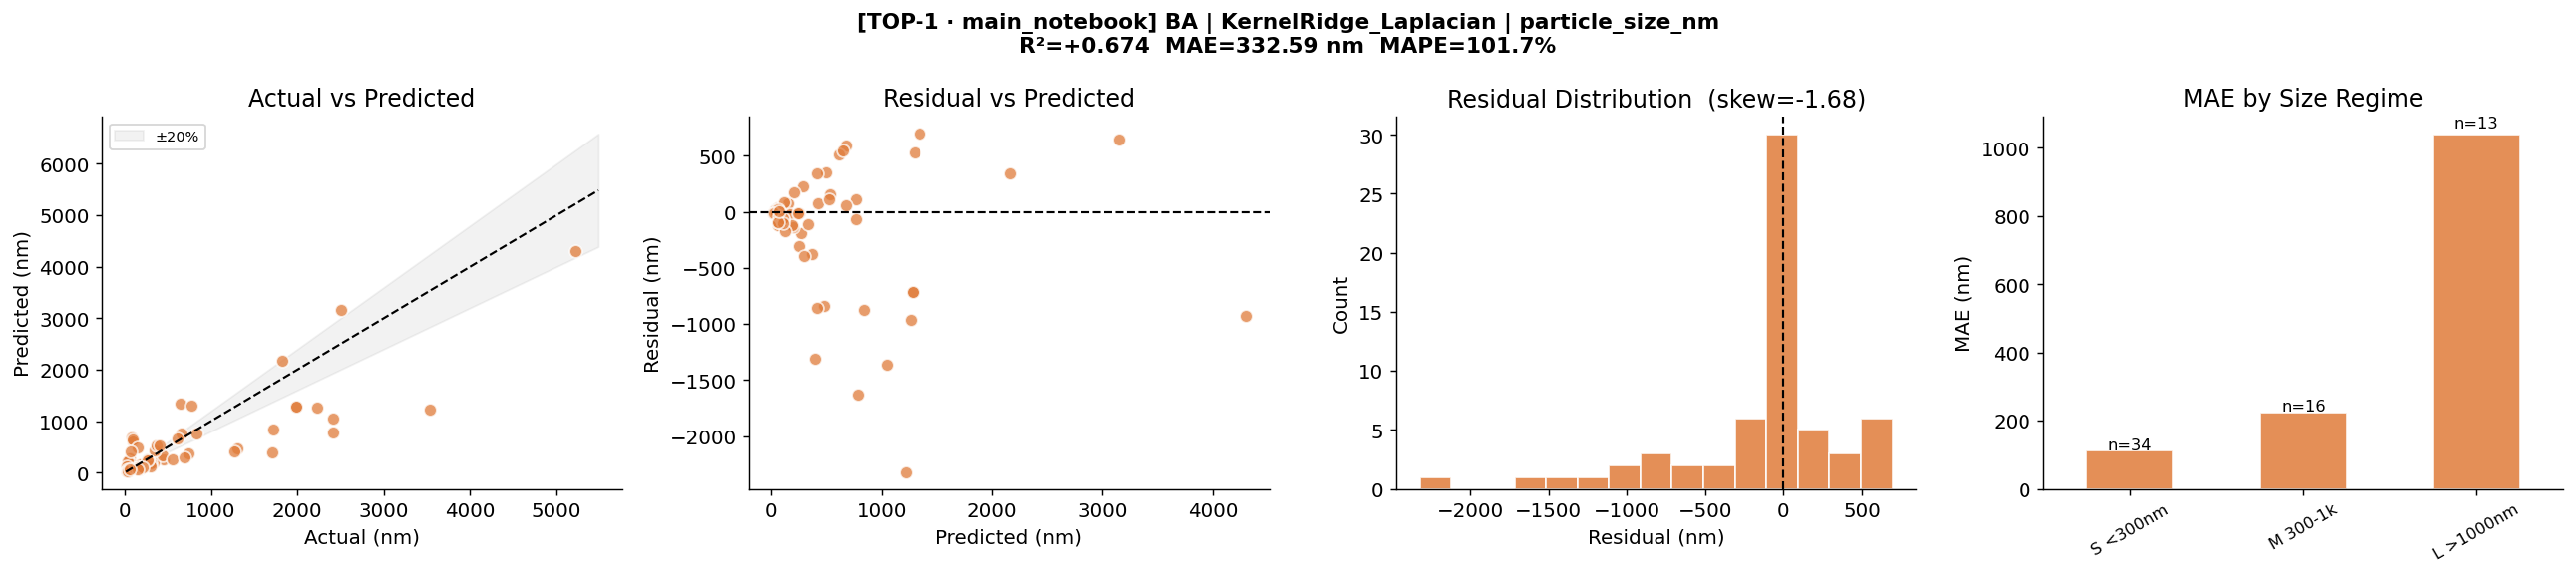

  Saved: deepdive_BA_particle_KernelRidge_Laplacian.png


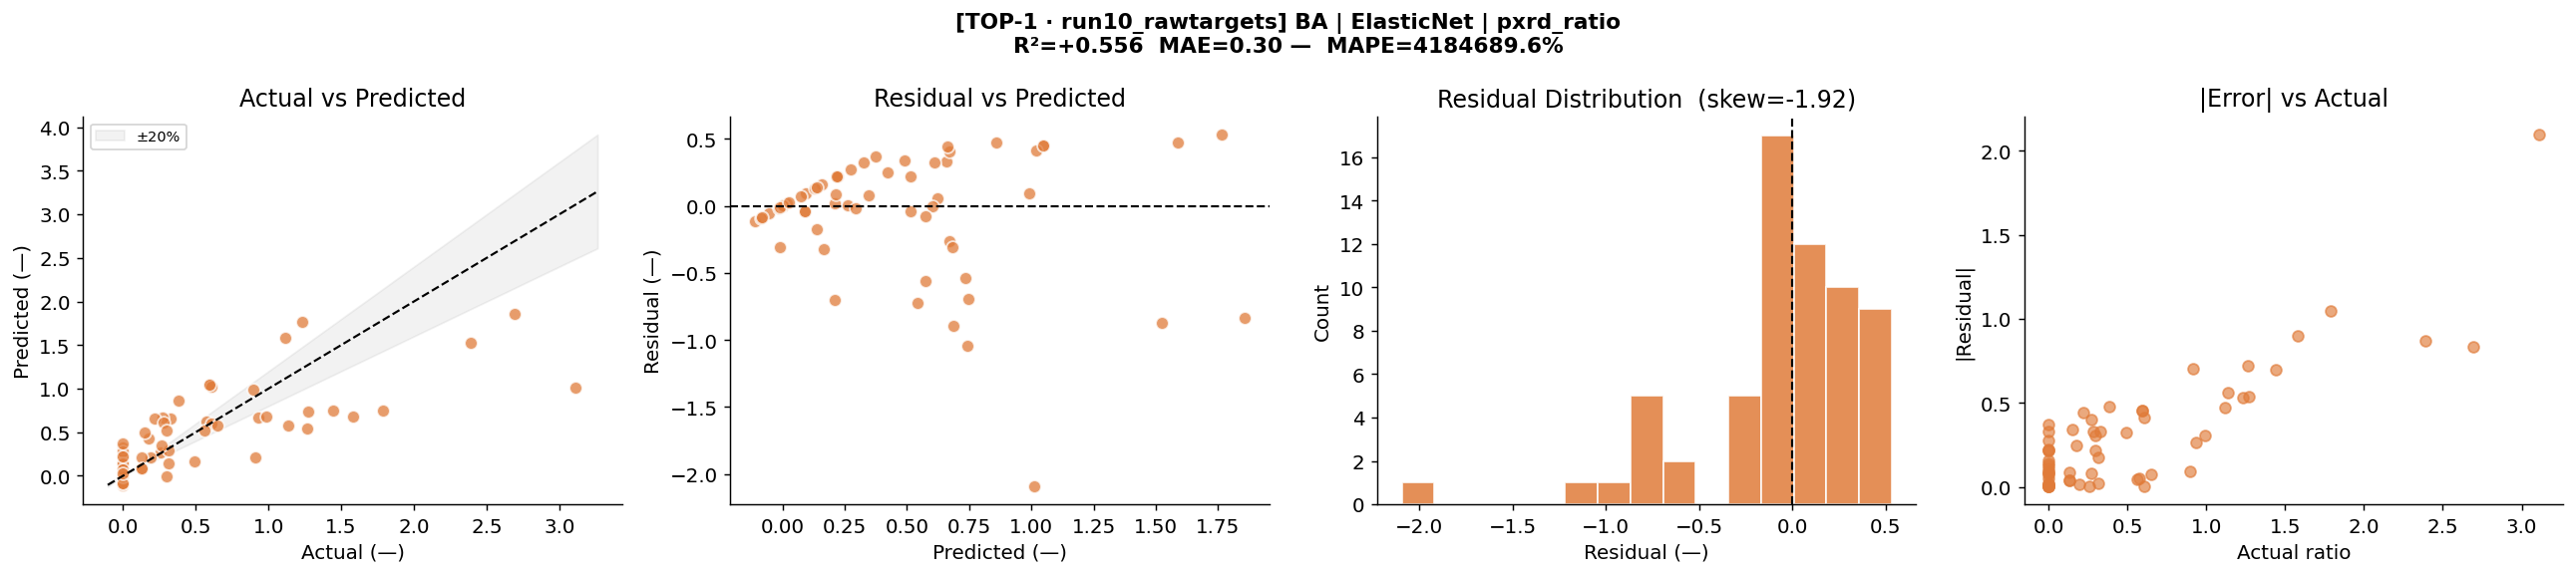

  Saved: deepdive_BA_pxrd_rat_ElasticNet.png


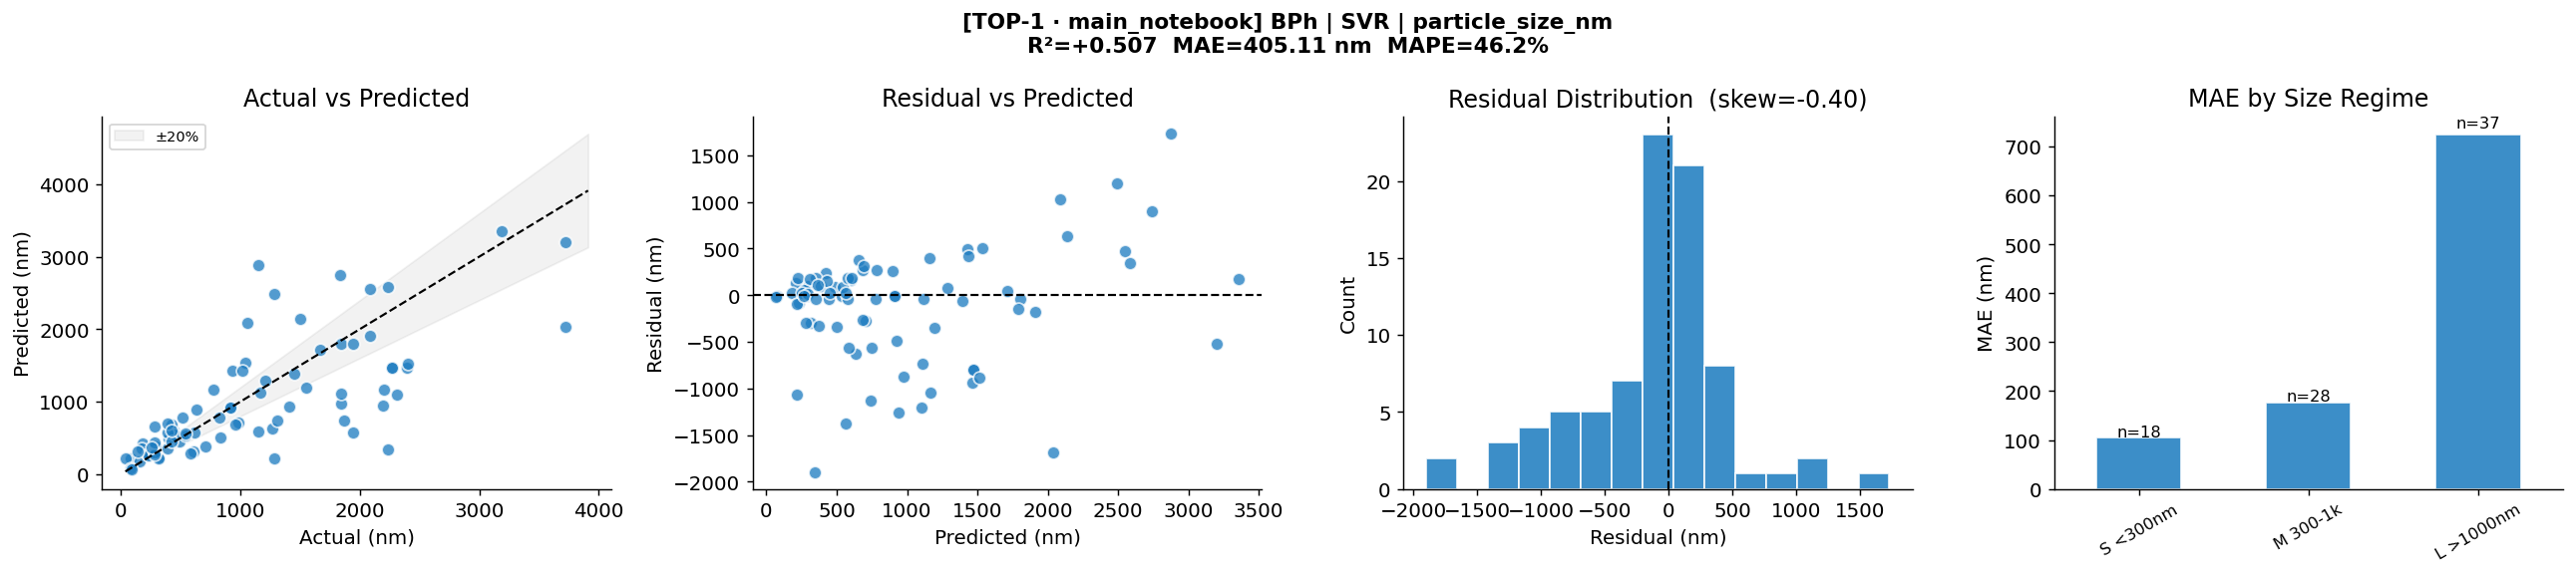

  Saved: deepdive_BPh_particle_SVR.png


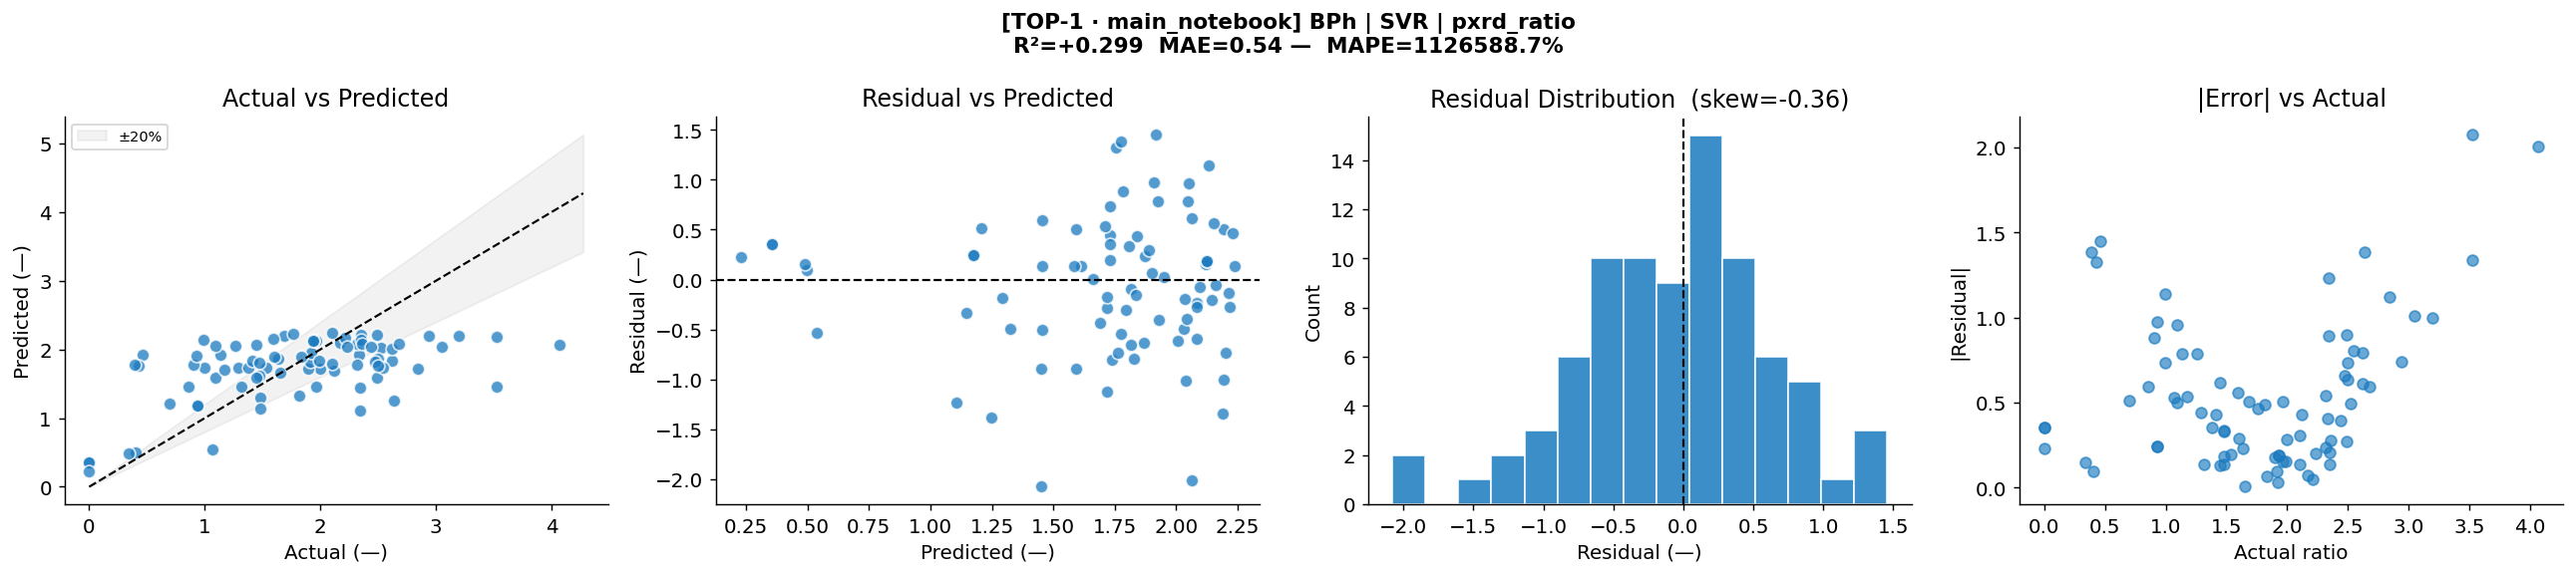

  Saved: deepdive_BPh_pxrd_rat_SVR.png


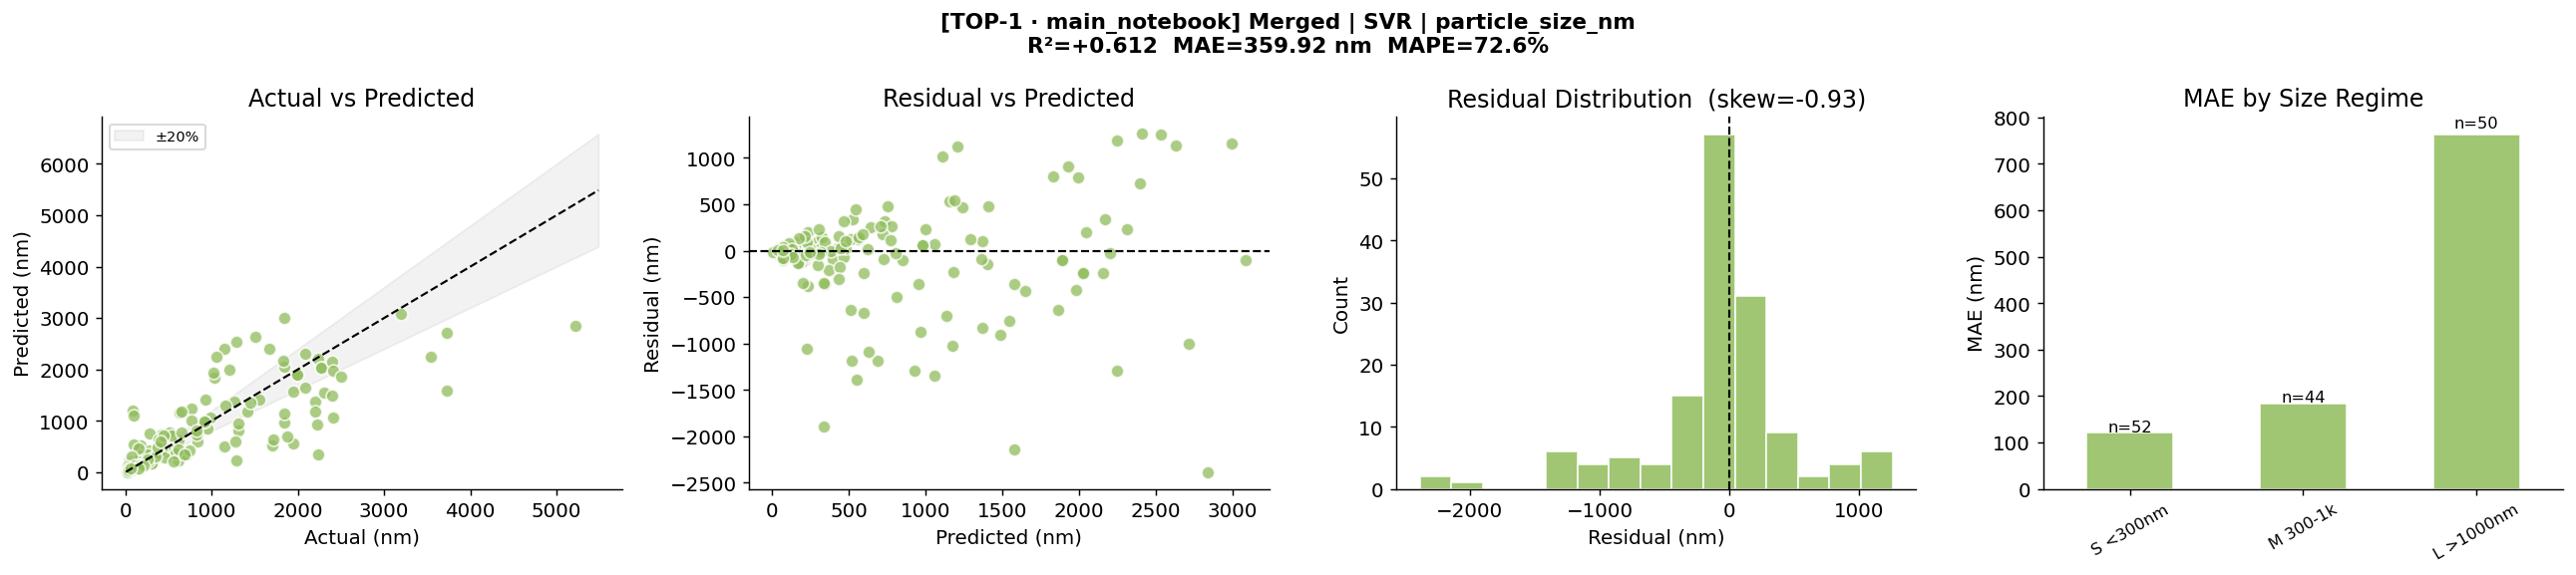

  Saved: deepdive_Merged_particle_SVR.png


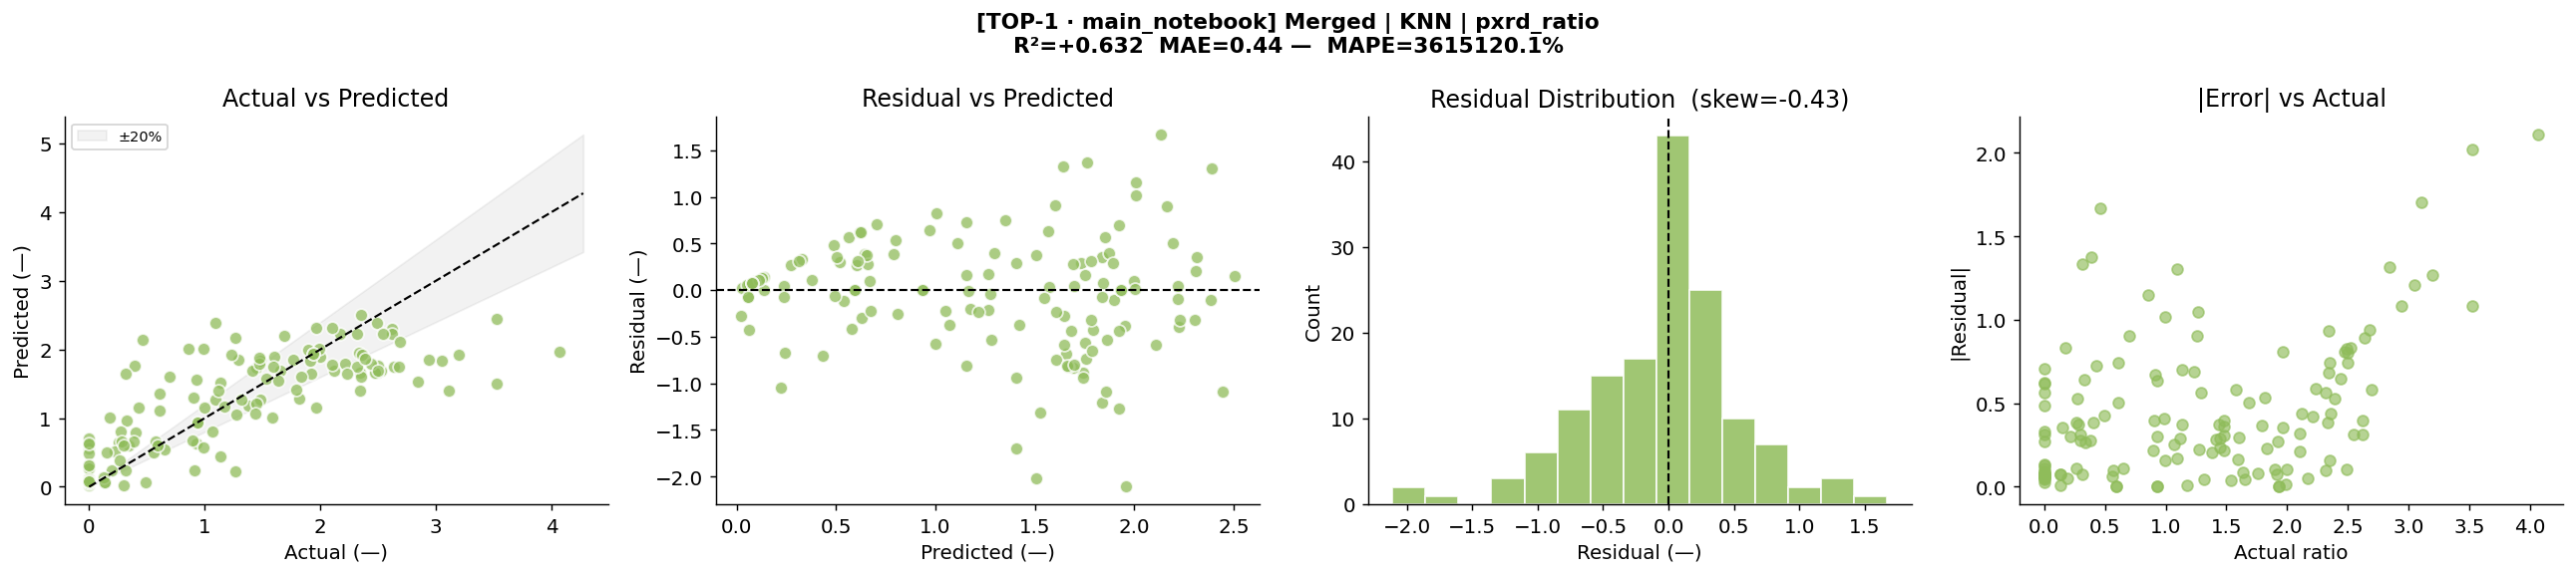

  Saved: deepdive_Merged_pxrd_rat_KNN.png


In [ ]:
def deep_dive_plot(w, title_prefix=""):
    ds      = w["dataset"]; tgt = w["target"]; unit = w["unit"]
    y_true  = w["y_true"];  y_pred = w["y_pred"]
    residuals = y_pred - y_true
    color   = PALETTE.get(ds, "#888888")
    r2_v    = r2_score(y_true, y_pred)
    mae_v   = mean_absolute_error(y_true, y_pred)
    mape_v  = np.mean(np.abs(residuals / (y_true + 1e-9))) * 100

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
    fig.suptitle(f"{title_prefix}{ds} | {w['entry']['model']} | {tgt}\n"
                 f"R²={r2_v:+.3f}  MAE={mae_v:.2f} {unit}  MAPE={mape_v:.1f}%",
                 fontsize=12, fontweight="bold")

    # 1. Actual vs Predicted
    ax = axes[0]
    vmin = min(y_true.min(), y_pred.min()) * 0.95
    vmax = max(y_true.max(), y_pred.max()) * 1.05
    xl   = np.linspace(vmin, vmax, 100)
    ax.fill_between(xl, xl*0.8, xl*1.2, alpha=0.1, color="gray", label="±20%")
    ax.scatter(y_true, y_pred, alpha=0.75, color=color, edgecolors="white", s=50)
    ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.2)
    ax.set_xlabel(f"Actual ({unit})"); ax.set_ylabel(f"Predicted ({unit})")
    ax.set_title("Actual vs Predicted"); ax.legend(fontsize=8)

    # 2. Residual vs Predicted
    ax = axes[1]
    ax.scatter(y_pred, residuals, alpha=0.75, color=color, edgecolors="white", s=50)
    ax.axhline(0, color="black", lw=1.2, ls="--")
    ax.set_xlabel(f"Predicted ({unit})"); ax.set_ylabel(f"Residual ({unit})")
    ax.set_title("Residual vs Predicted")

    # 3. Residual histogram
    ax = axes[2]
    ax.hist(residuals, bins=15, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="black", lw=1.2, ls="--")
    ax.set_xlabel(f"Residual ({unit})"); ax.set_ylabel("Count")
    ax.set_title(f"Residual Distribution  (skew={pd.Series(residuals).skew():.2f})")

    # 4. MAE by regime (particle size only) or |error| vs actual (pxrd)
    ax = axes[3]
    if tgt == "particle_size_nm":
        labels = pd.cut(y_true,
                        bins=[0, SIZE_SMALL_MAX, SIZE_MEDIUM_MAX, np.inf],
                        labels=["S <300nm", "M 300-1k", "L >1000nm"])
        mae_r = pd.Series(np.abs(residuals)).groupby(labels).mean()
        n_r   = pd.Series(np.abs(residuals)).groupby(labels).count()
        mae_r.plot(kind="bar", ax=ax, color=color, alpha=0.85, edgecolor="white")
        ax.set_ylabel("MAE (nm)"); ax.set_xticklabels(mae_r.index, rotation=30, fontsize=9)
        for i, (v, n) in enumerate(zip(mae_r, n_r)):
            ax.text(i, v*1.02, f"n={n}", ha="center", fontsize=9)
        ax.set_title("MAE by Size Regime")
    else:
        ax.scatter(y_true, np.abs(residuals), alpha=0.65, color=color)
        ax.set_xlabel("Actual ratio"); ax.set_ylabel("|Residual|")
        ax.set_title("|Error| vs Actual")

    plt.tight_layout()
    fname = f"deepdive_{ds}_{tgt[:8]}_{w['entry']['model'].replace(' ','_')}.png"
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"  Saved: {fname}")

for key, w in BEST6.items():
    deep_dive_plot(w, title_prefix=f"[TOP-1 · {w['source']}] ")


## 14. Permutation Importance

Shuffles each feature 30 times and records R² drop, computed in whatever space the model was actually trained in (`train_target_col`). Works for any model family. Runs on the **6 top-1 models** only.


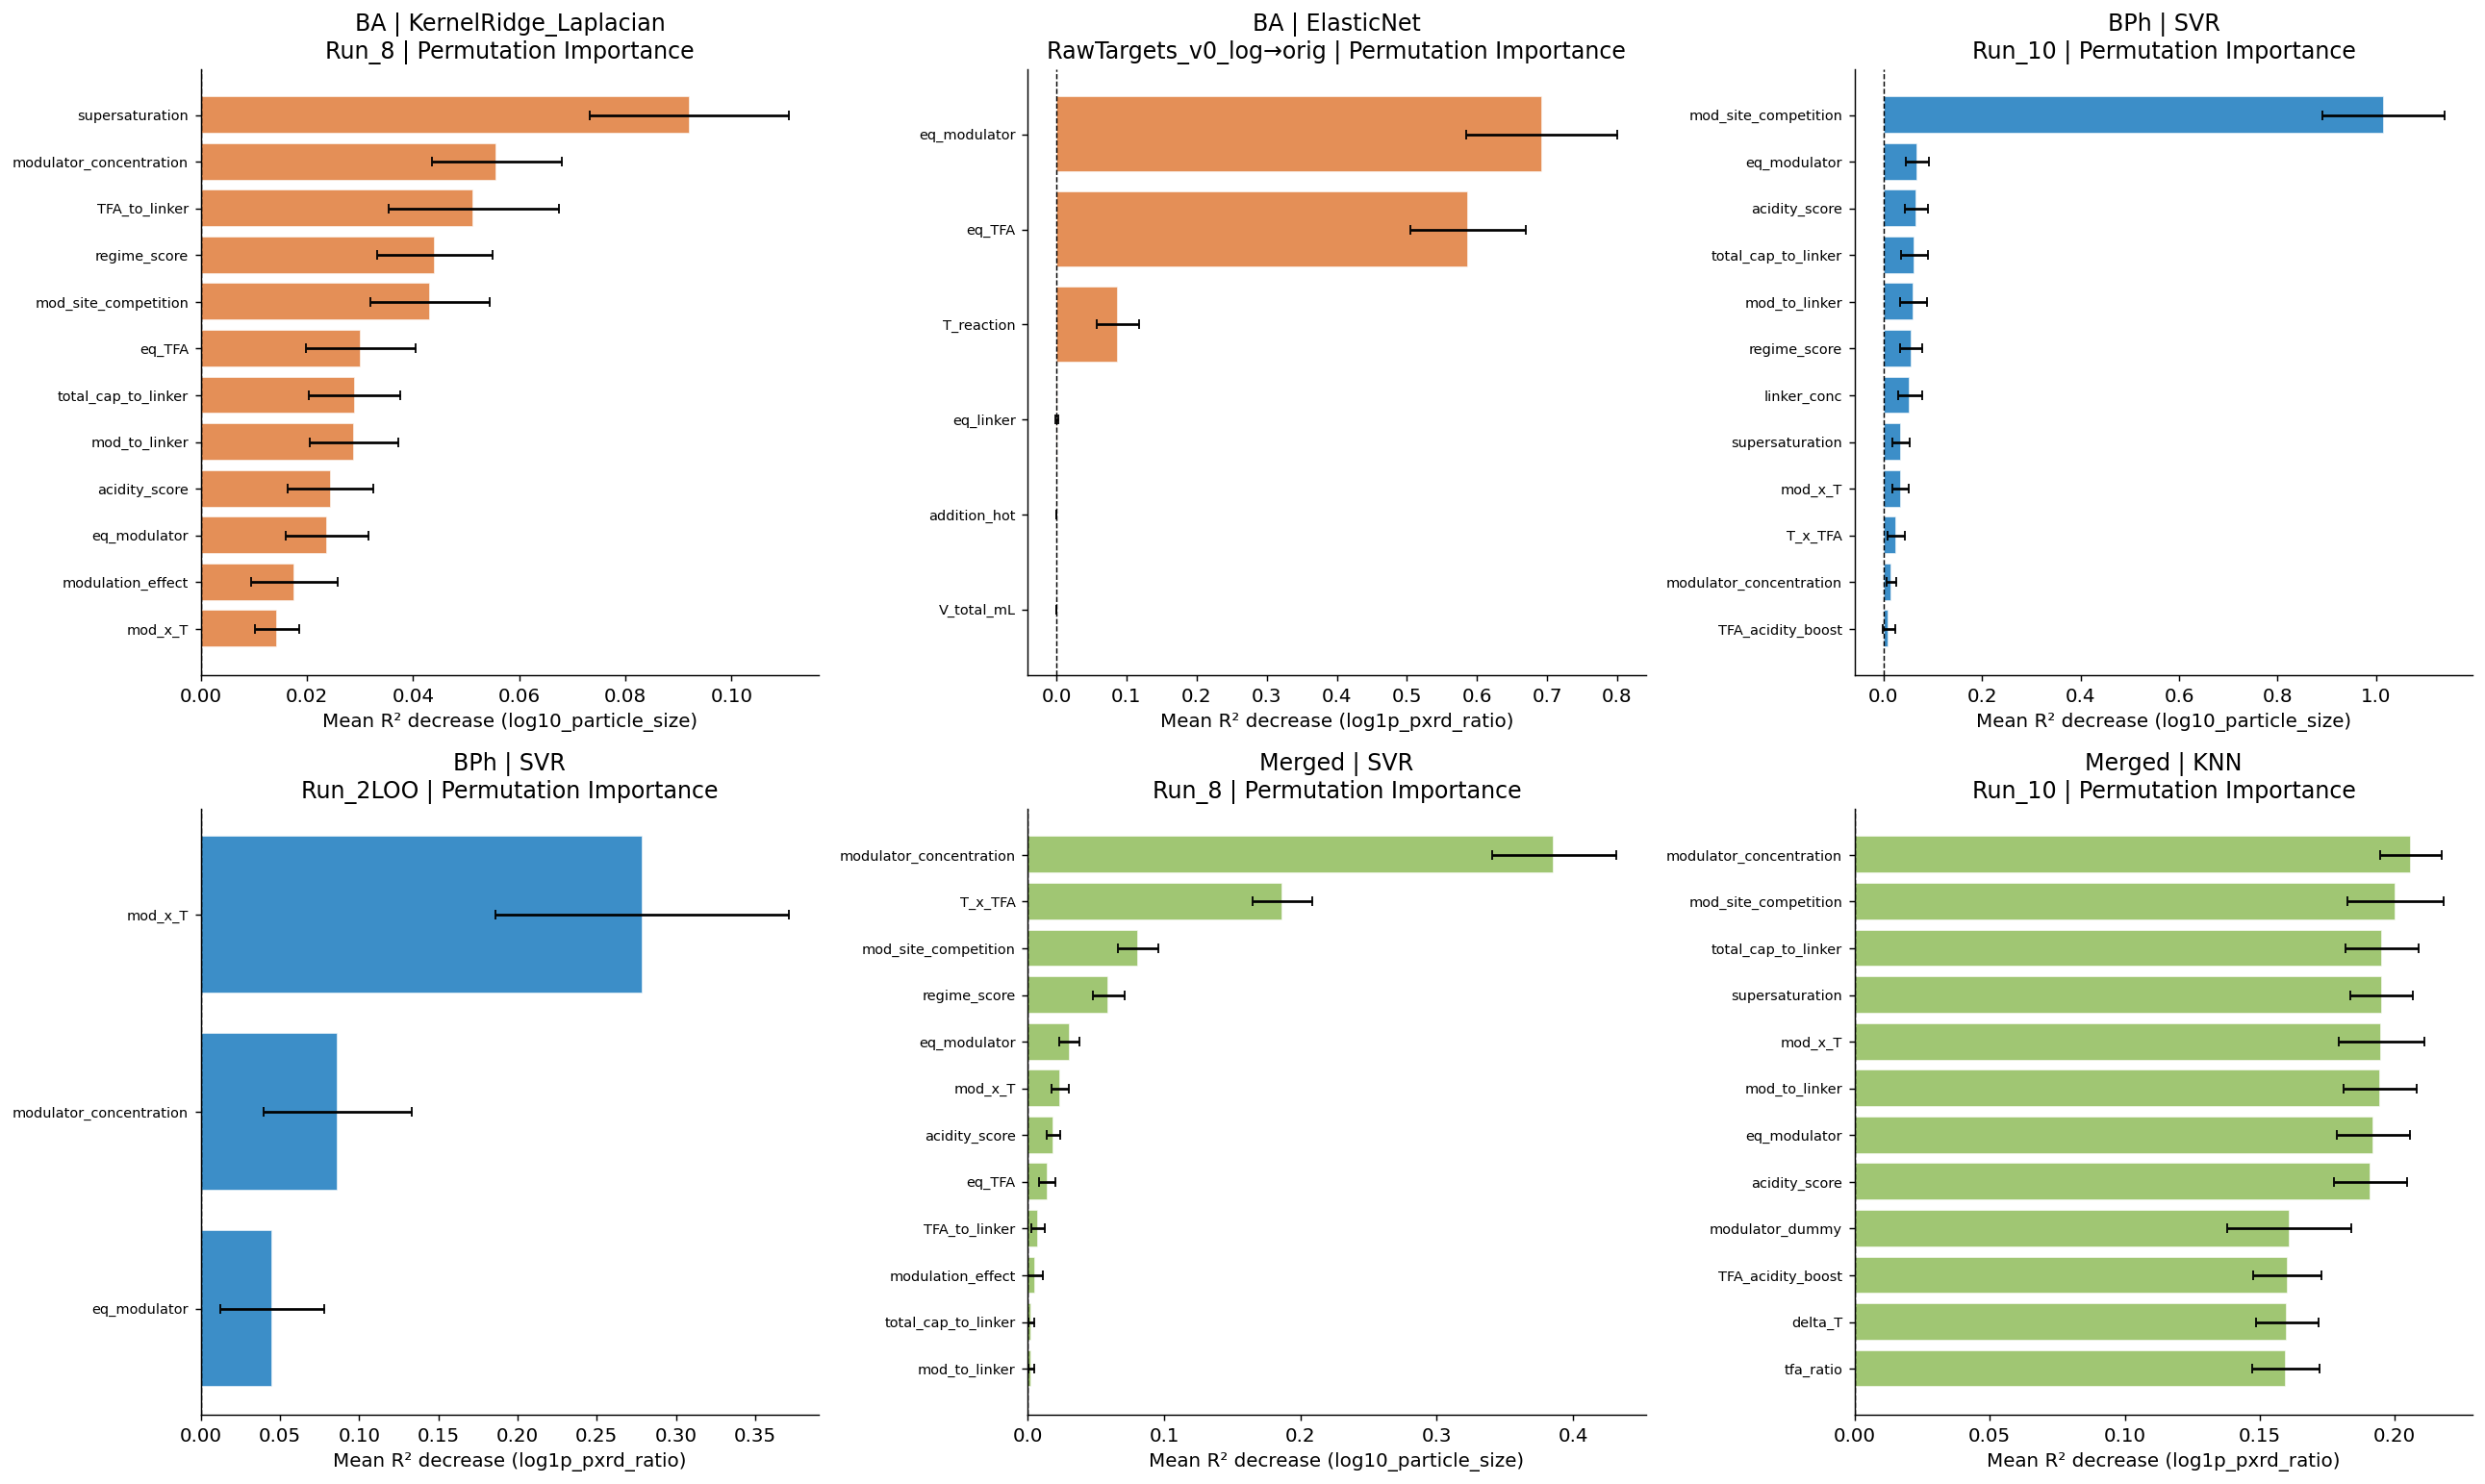

In [ ]:
def plot_perm_importance(w, ax):
    ds         = w["dataset"]; entry = w["entry"]
    sel_feats  = w["sel_feats"]
    df_this    = {"BPh": bph, "BA": ba, "Merged": merged}[ds]
    train_col  = w["train_target_col"]
    y_train    = df_this[train_col].values
    X          = df_this[sel_feats].fillna(df_this[sel_feats].median()).values
    pipe       = entry["fitted_pipeline"]
    perm = permutation_importance(pipe, X, y_train, n_repeats=30,
                                   random_state=42, n_jobs=-1)
    order = np.argsort(perm.importances_mean)[-min(12, len(sel_feats)):]
    color = PALETTE.get(ds, "#888")
    ax.barh([sel_feats[i] for i in order], perm.importances_mean[order],
             xerr=perm.importances_std[order], color=color, alpha=0.85,
             edgecolor="white", capsize=3)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel(f"Mean R² decrease ({train_col})")
    ax.set_title(f"{ds} | {entry['model']}\n{w['run']} | Permutation Importance")
    ax.tick_params(axis="y", labelsize=8)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, (key, w) in zip(axes.flatten(), BEST6.items()):
    plot_perm_importance(w, ax)
plt.tight_layout()
plt.savefig("permutation_importance_top1.png", bbox_inches="tight", dpi=150)
plt.show()


## 15. Partial Dependence Plots

Marginal effect of the top-4 most important features, averaged over all other features. Runs on the **6 top-1 models** only.


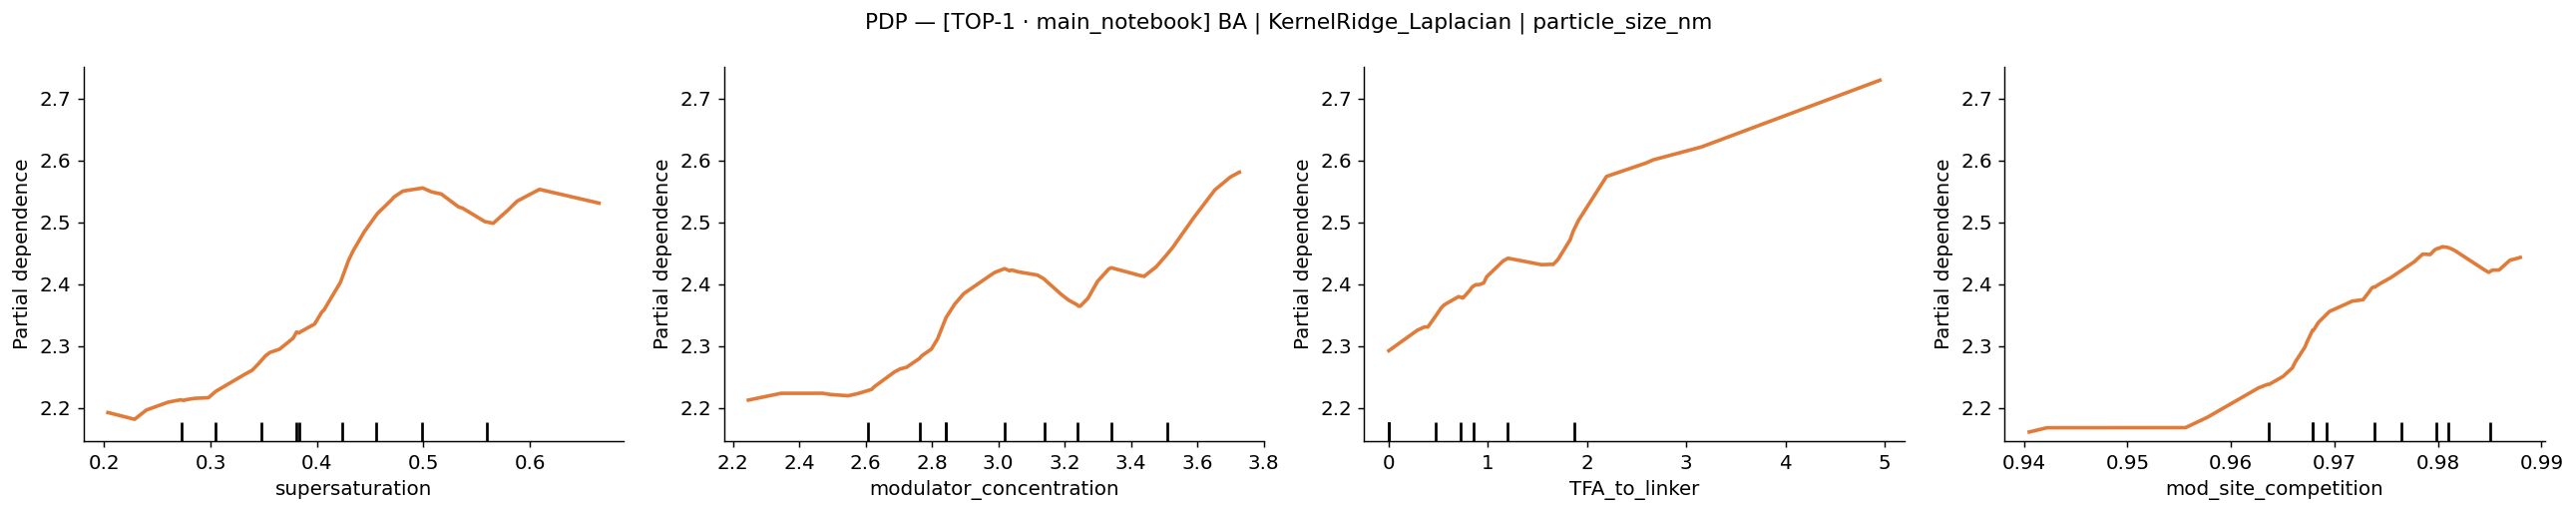

  Saved: pdp_BA_KernelRidge_Laplacian.png


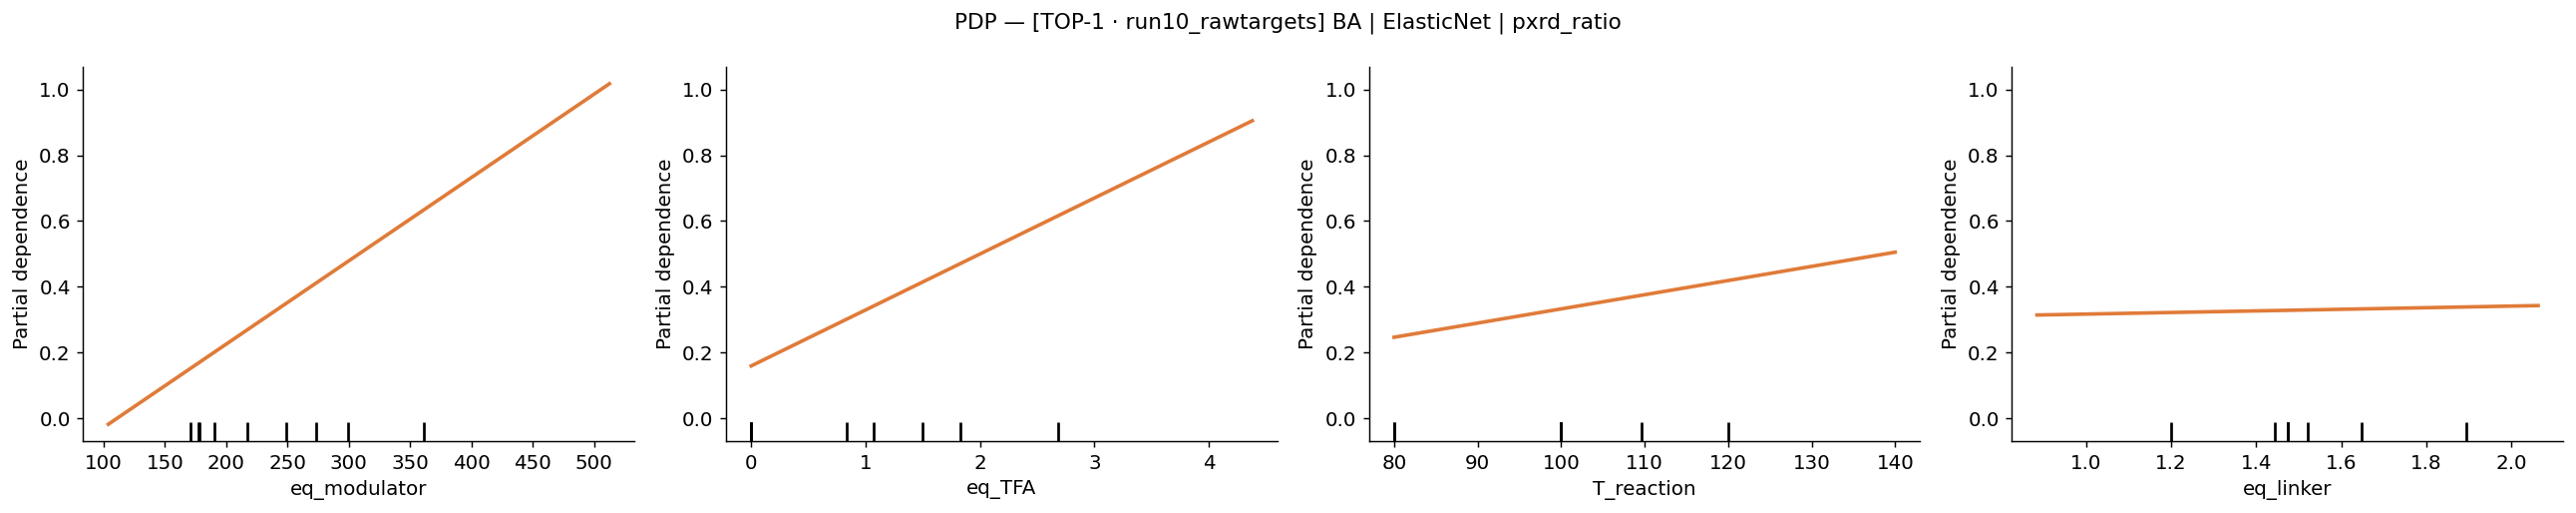

  Saved: pdp_BA_ElasticNet.png


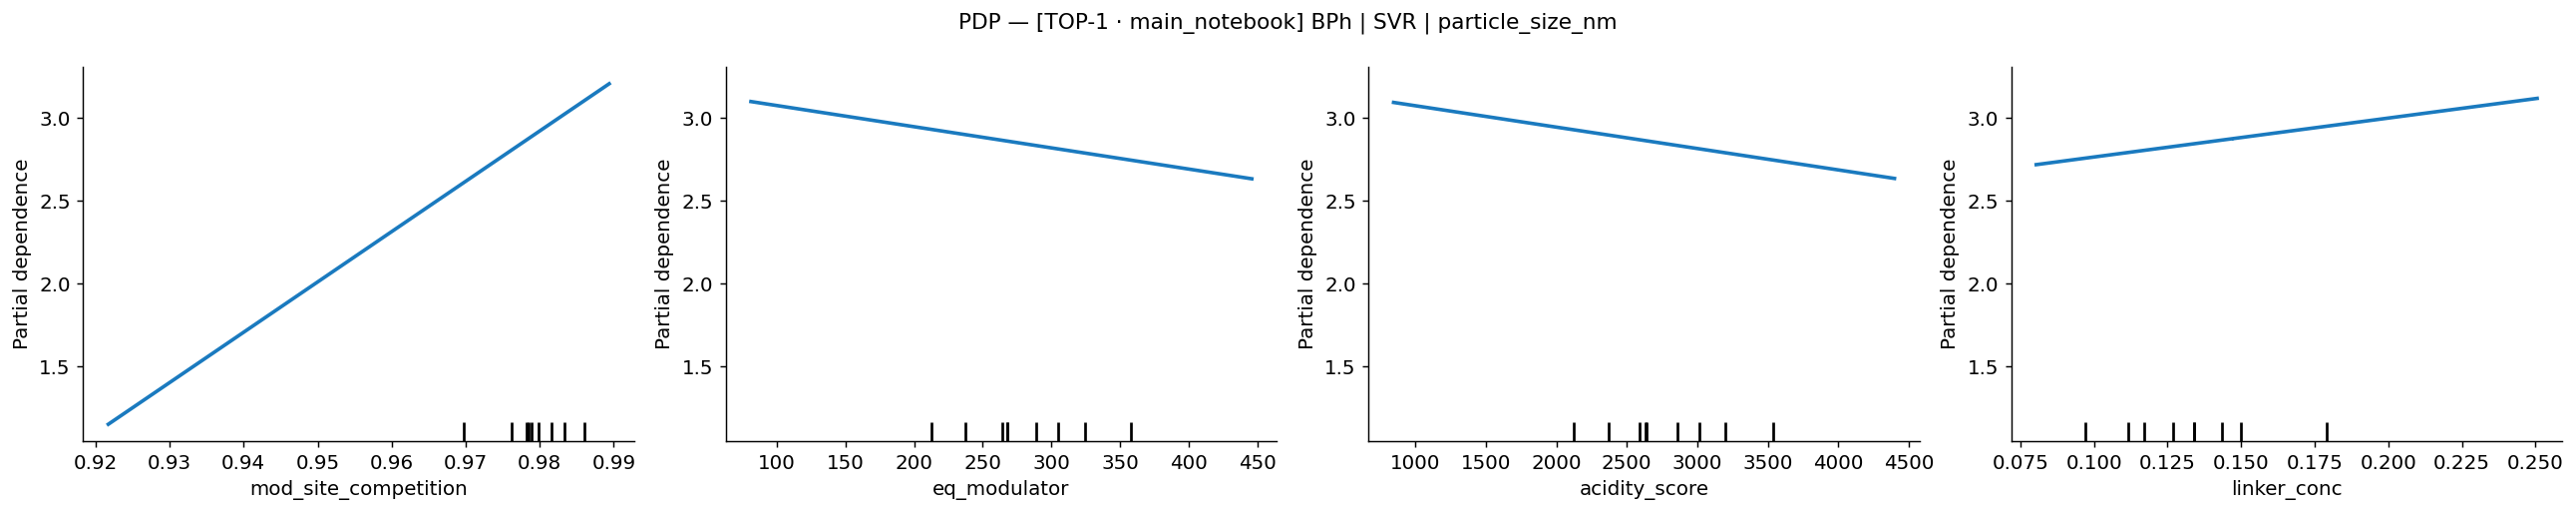

  Saved: pdp_BPh_SVR.png


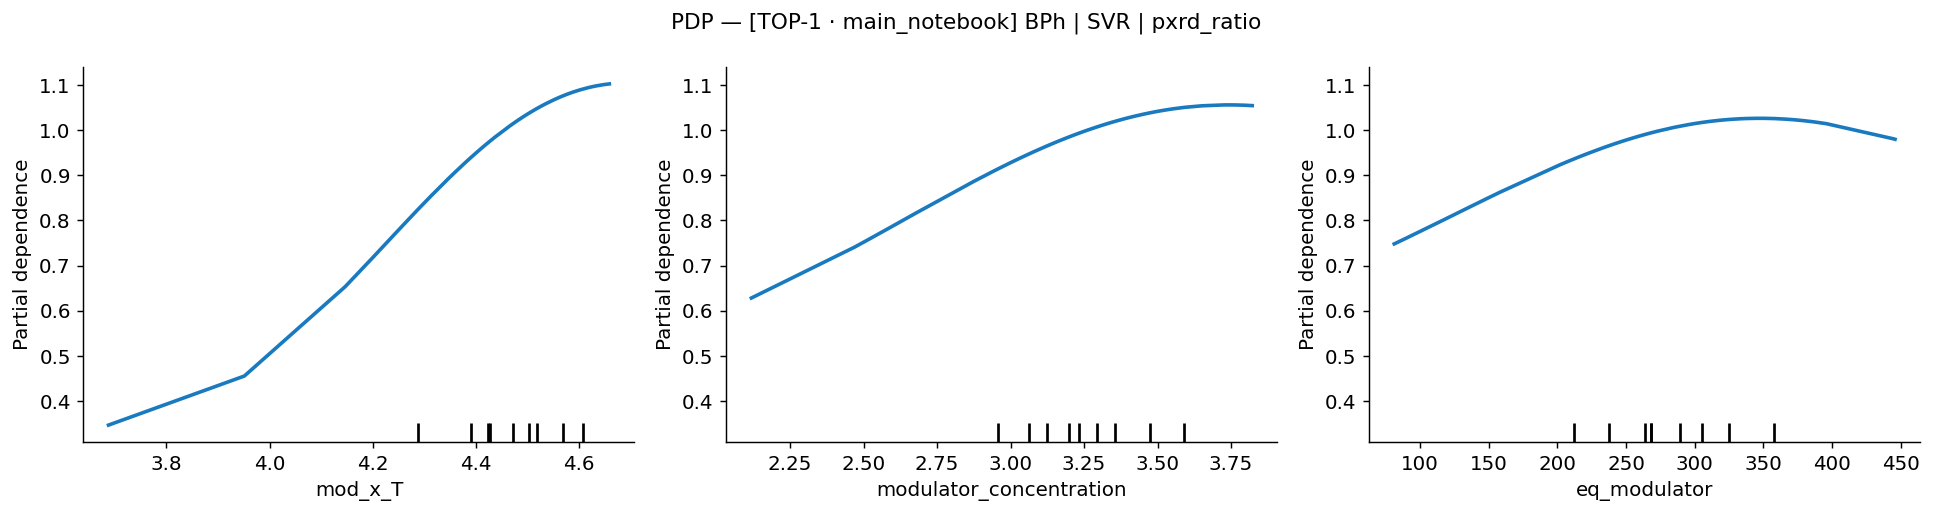

  Saved: pdp_BPh_SVR.png


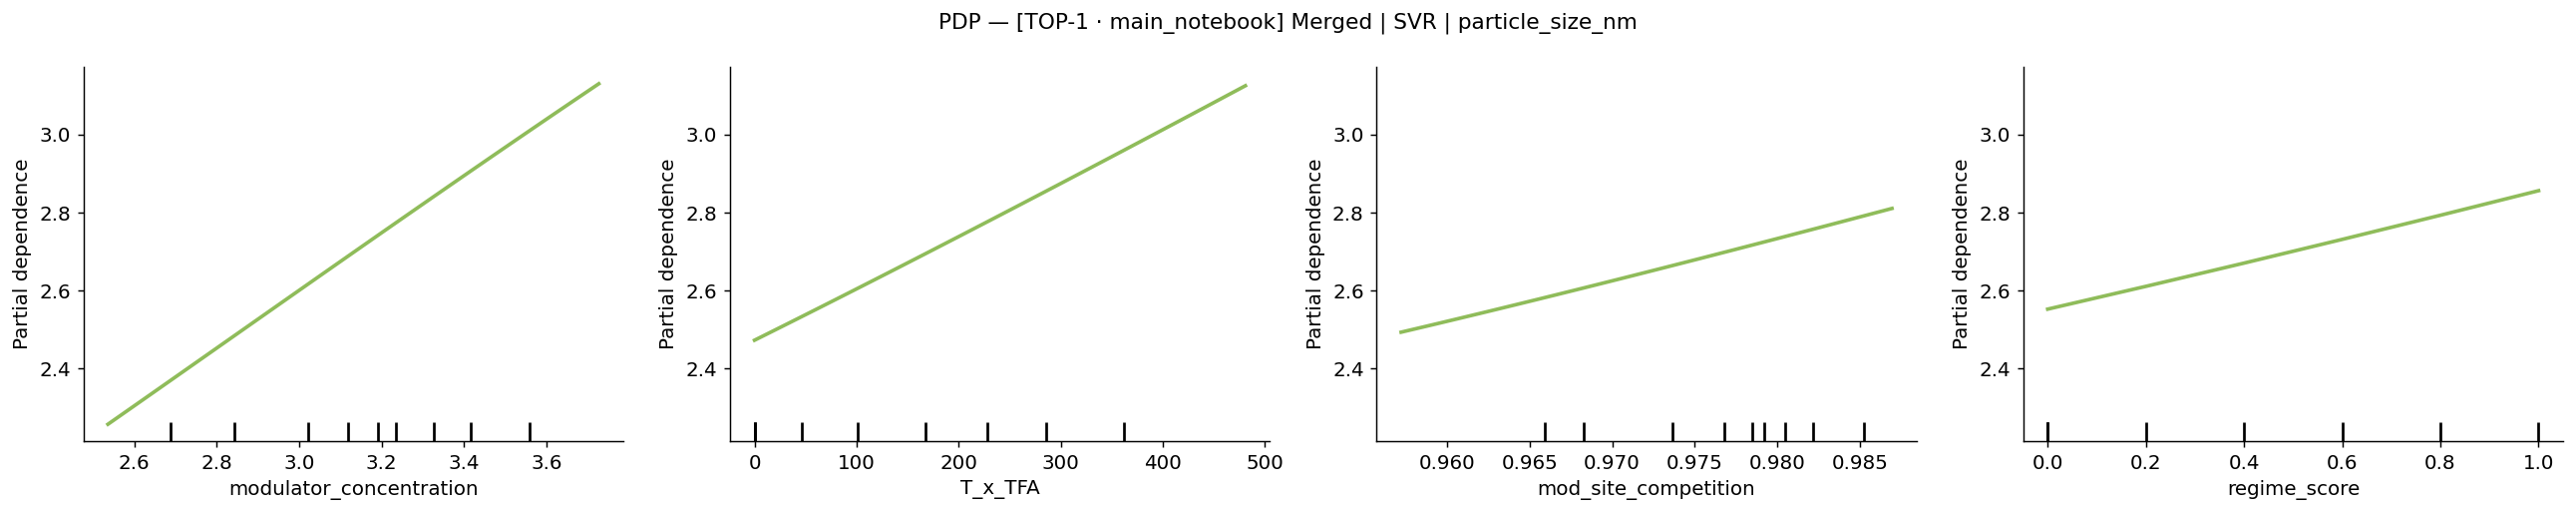

  Saved: pdp_Merged_SVR.png


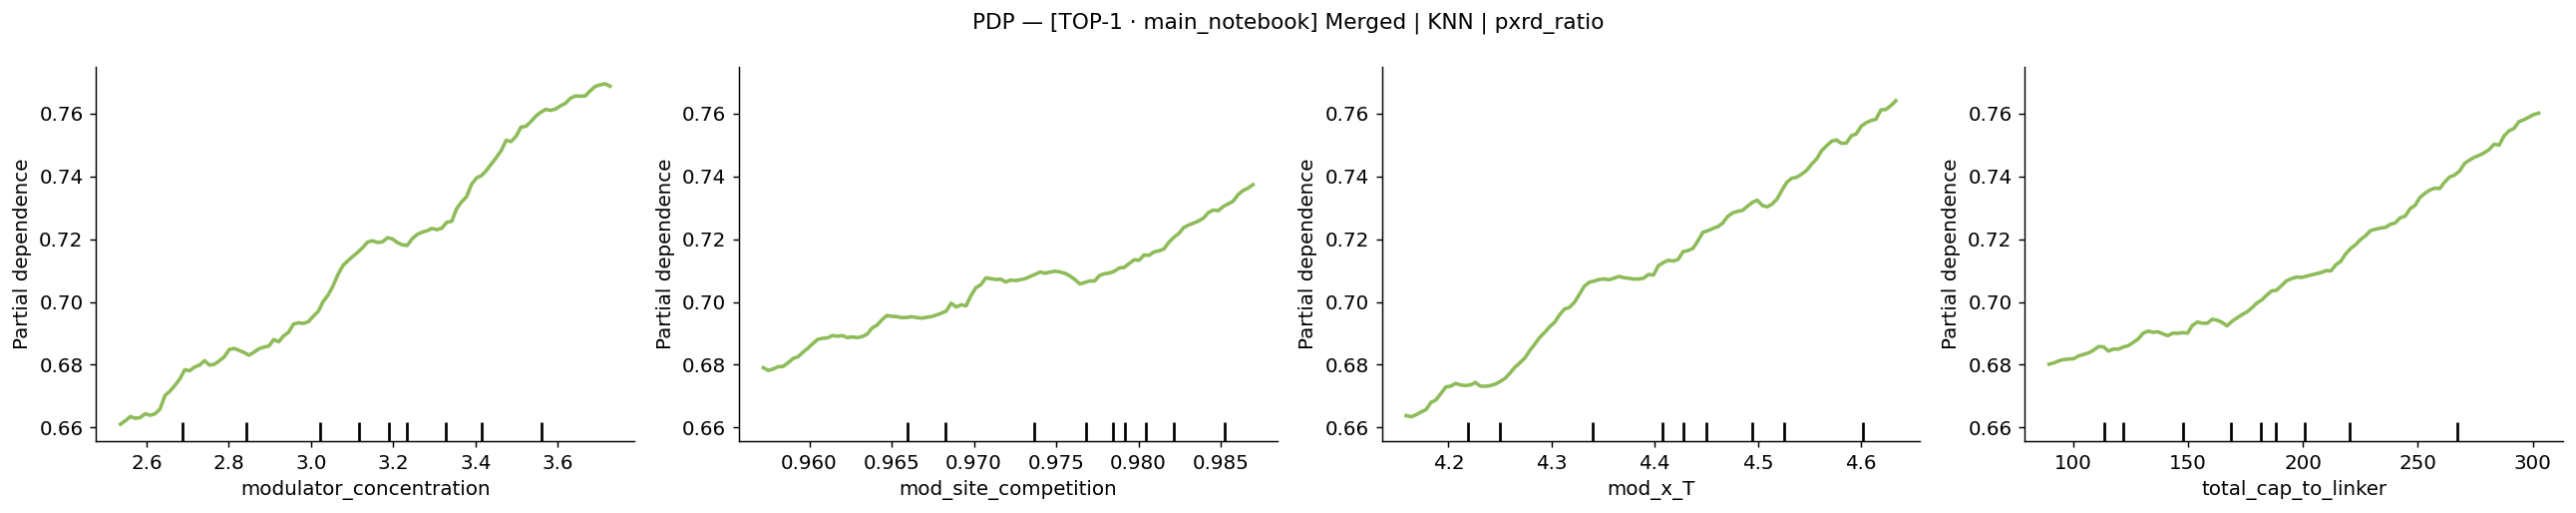

  Saved: pdp_Merged_KNN.png


In [ ]:
from sklearn.inspection import PartialDependenceDisplay

for key, w in BEST6.items():
    ds = w["dataset"]; entry = w["entry"]
    df_this    = {"BPh": bph, "BA": ba, "Merged": merged}[ds]
    sel_feats  = w["sel_feats"]
    train_col  = w["train_target_col"]
    X_df   = df_this[sel_feats].fillna(df_this[sel_feats].median())
    y_train = df_this[train_col].values
    pipe   = entry["fitted_pipeline"]

    perm = permutation_importance(pipe, X_df, y_train, n_repeats=15, random_state=42)
    n_top = min(4, len(sel_feats))
    top_idx = np.argsort(perm.importances_mean)[-n_top:][::-1]

    fig, axes = plt.subplots(1, n_top, figsize=(5 * n_top, 4))
    if n_top == 1:
        axes = [axes]
    fig.suptitle(f"PDP — [TOP-1 · {w['source']}] {ds} | {entry['model']} | {w['target']}", fontsize=12)
    PartialDependenceDisplay.from_estimator(
        pipe, X_df, list(top_idx), feature_names=sel_feats,
        ax=axes, line_kw={"color": PALETTE.get(ds, "#888"), "lw": 2})
    plt.tight_layout()
    fname = f"pdp_{ds}_{entry['model'].replace(' ','_')}.png"
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"  Saved: {fname}")


## 16. Model Internals

How each of the **6 top-1 models** works internally. Auto-detects model family and plots accordingly.



═════════════════════════════════════════════════════════════════
  BA | KernelRidge_Laplacian | particle_size_nm
═════════════════════════════════════════════════════════════════


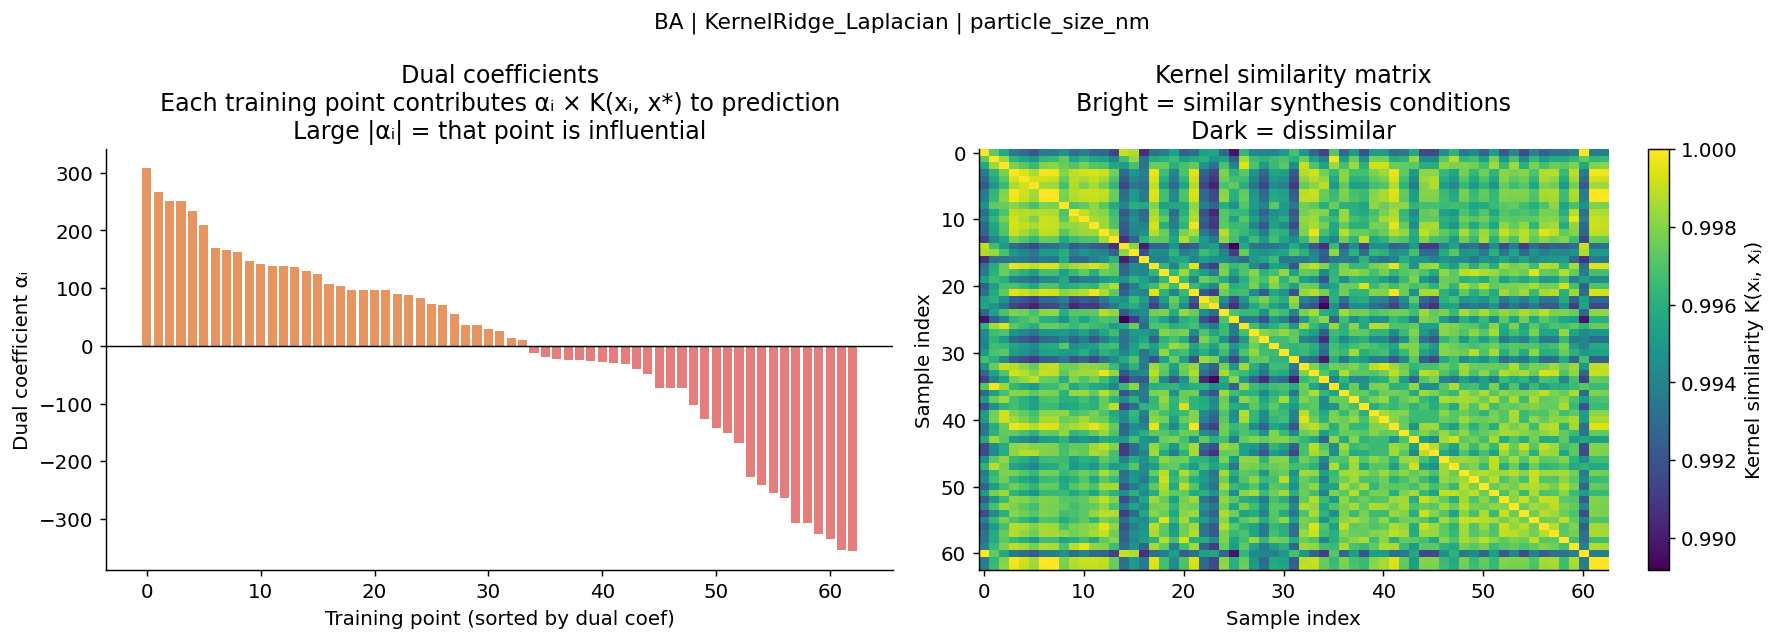

  → KernelRidge: kernel='laplacian'  α=0.00134  γ=0.000346
  → n_dual_coef=63  max|α|=355.346  influential points: 7

═════════════════════════════════════════════════════════════════
  BA | ElasticNet | pxrd_ratio
═════════════════════════════════════════════════════════════════


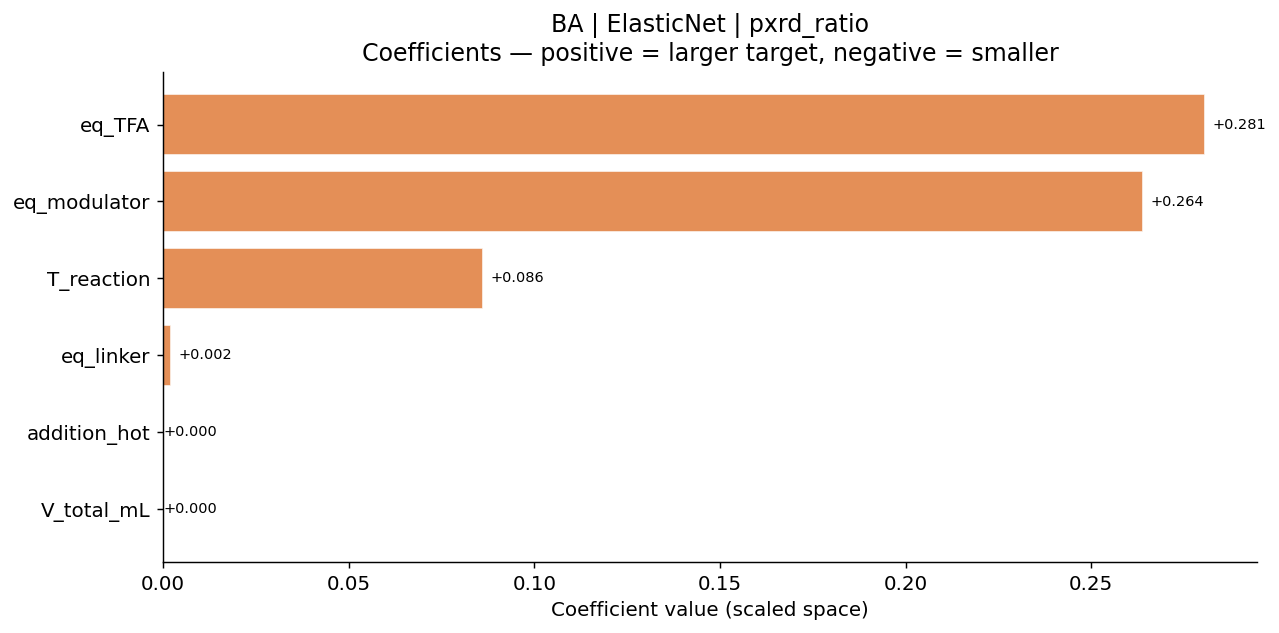

  → ElasticNet/linear: top feature by |coef| = eq_TFA (+0.281)

═════════════════════════════════════════════════════════════════
  BPh | SVR | particle_size_nm
═════════════════════════════════════════════════════════════════


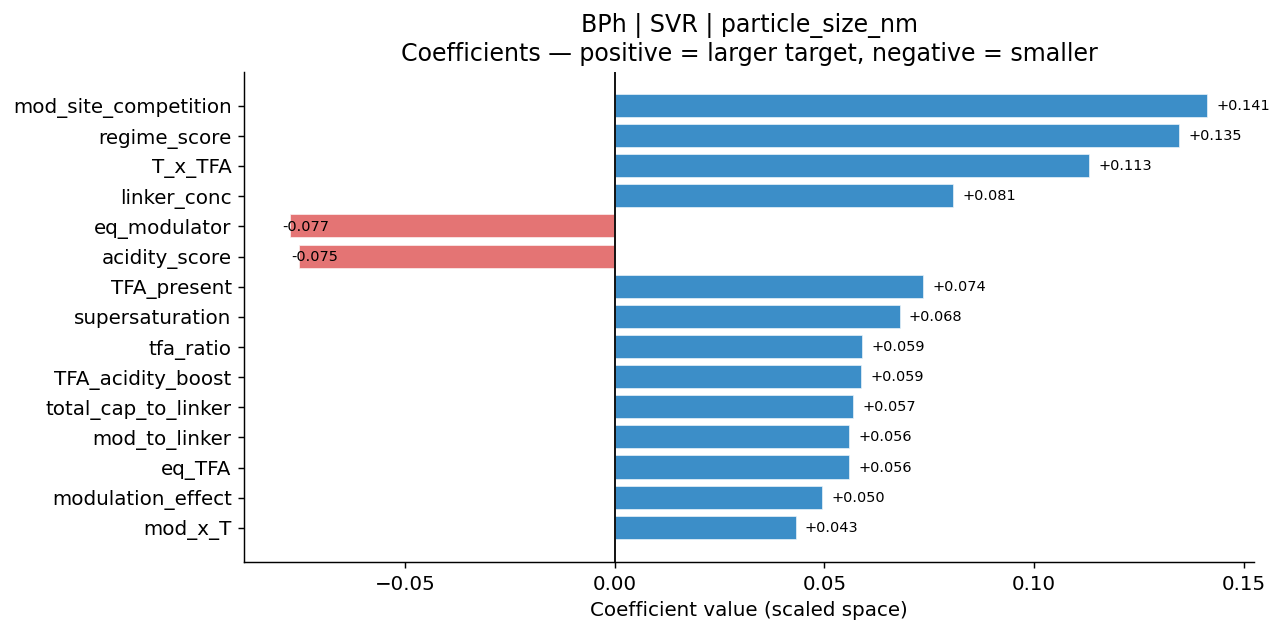

  → ElasticNet/linear: top feature by |coef| = mod_site_competition (+0.141)

═════════════════════════════════════════════════════════════════
  BPh | SVR | pxrd_ratio
═════════════════════════════════════════════════════════════════


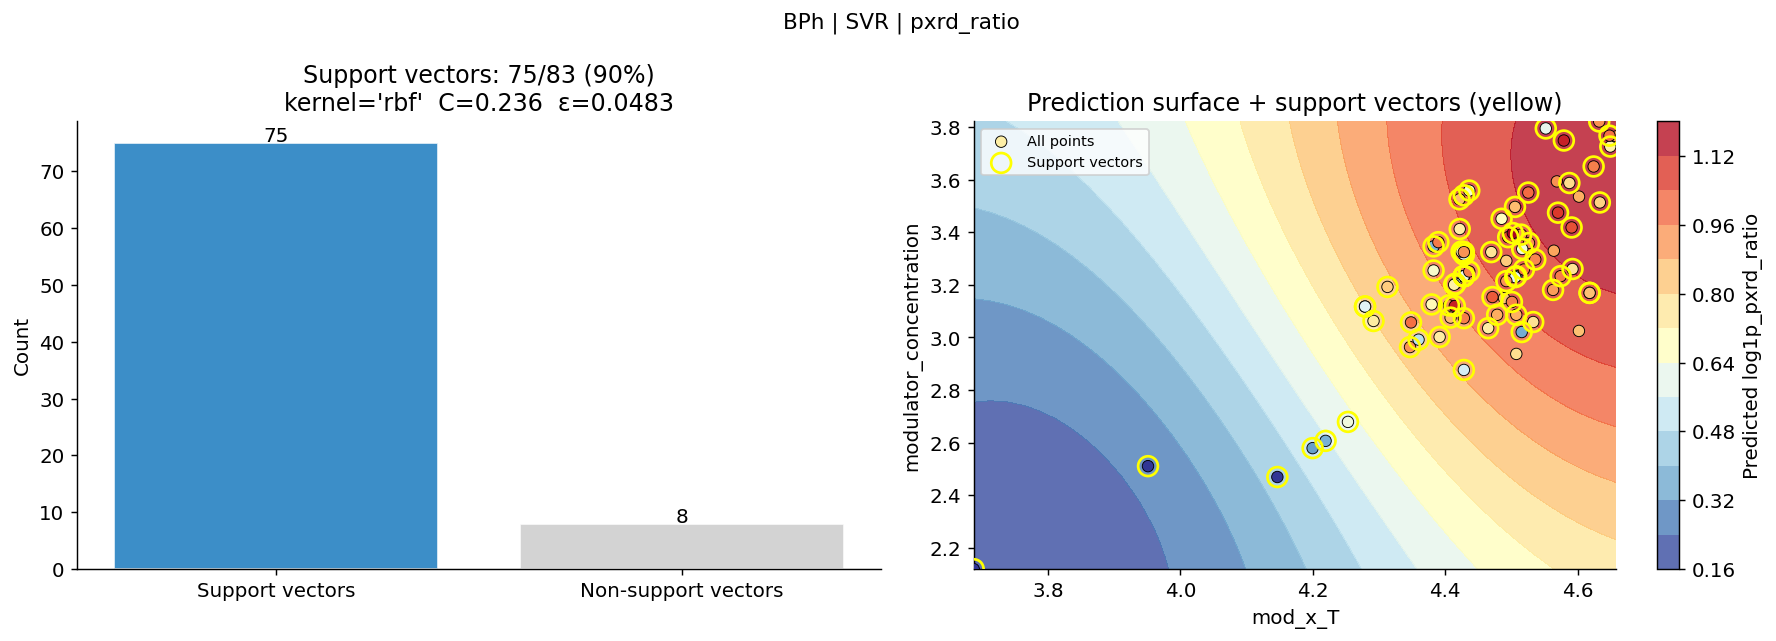

  → SVR: kernel='rbf'  C=0.236  ε=0.0483  n_SV=75/83 (90%)

═════════════════════════════════════════════════════════════════
  Merged | SVR | particle_size_nm
═════════════════════════════════════════════════════════════════


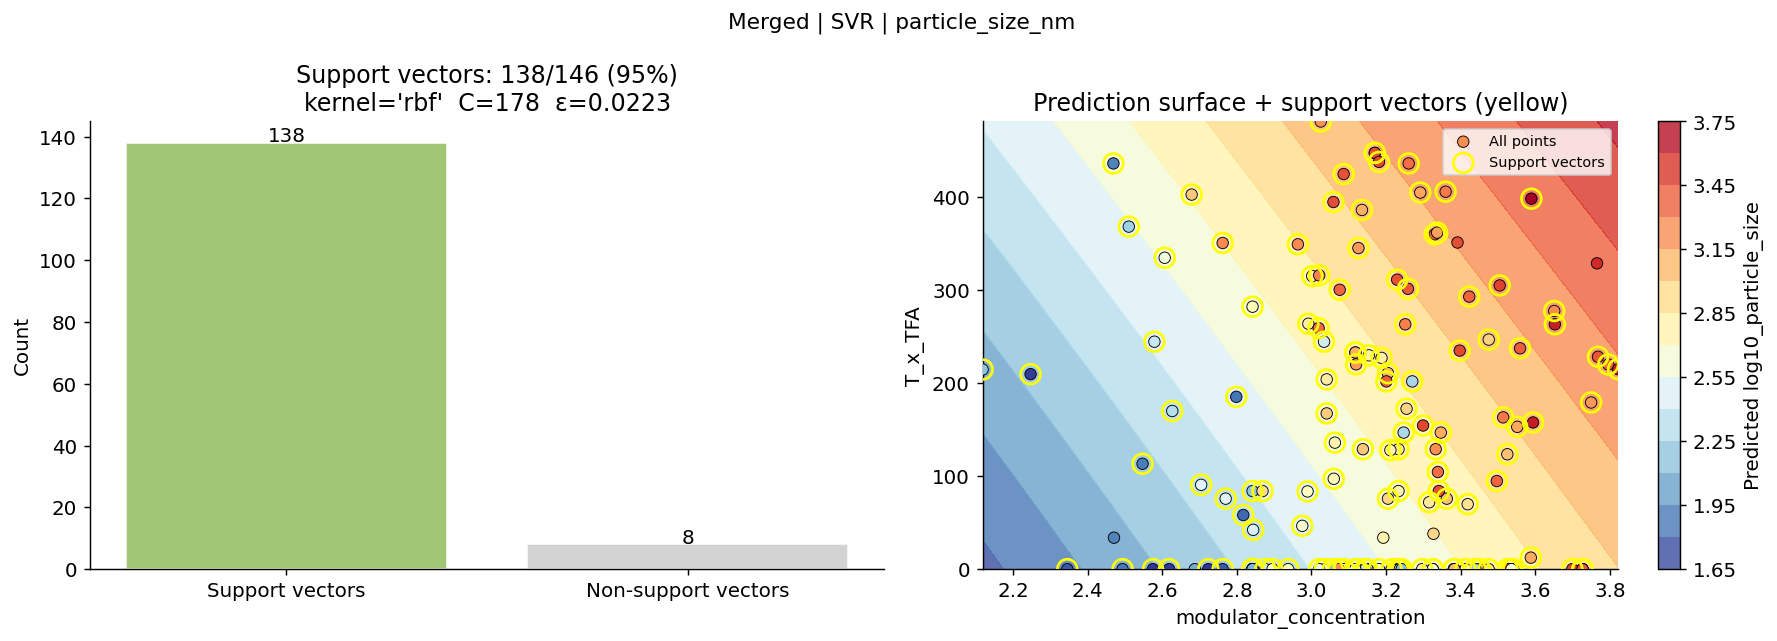

  → SVR: kernel='rbf'  C=178  ε=0.0223  n_SV=138/146 (95%)

═════════════════════════════════════════════════════════════════
  Merged | KNN | pxrd_ratio
═════════════════════════════════════════════════════════════════


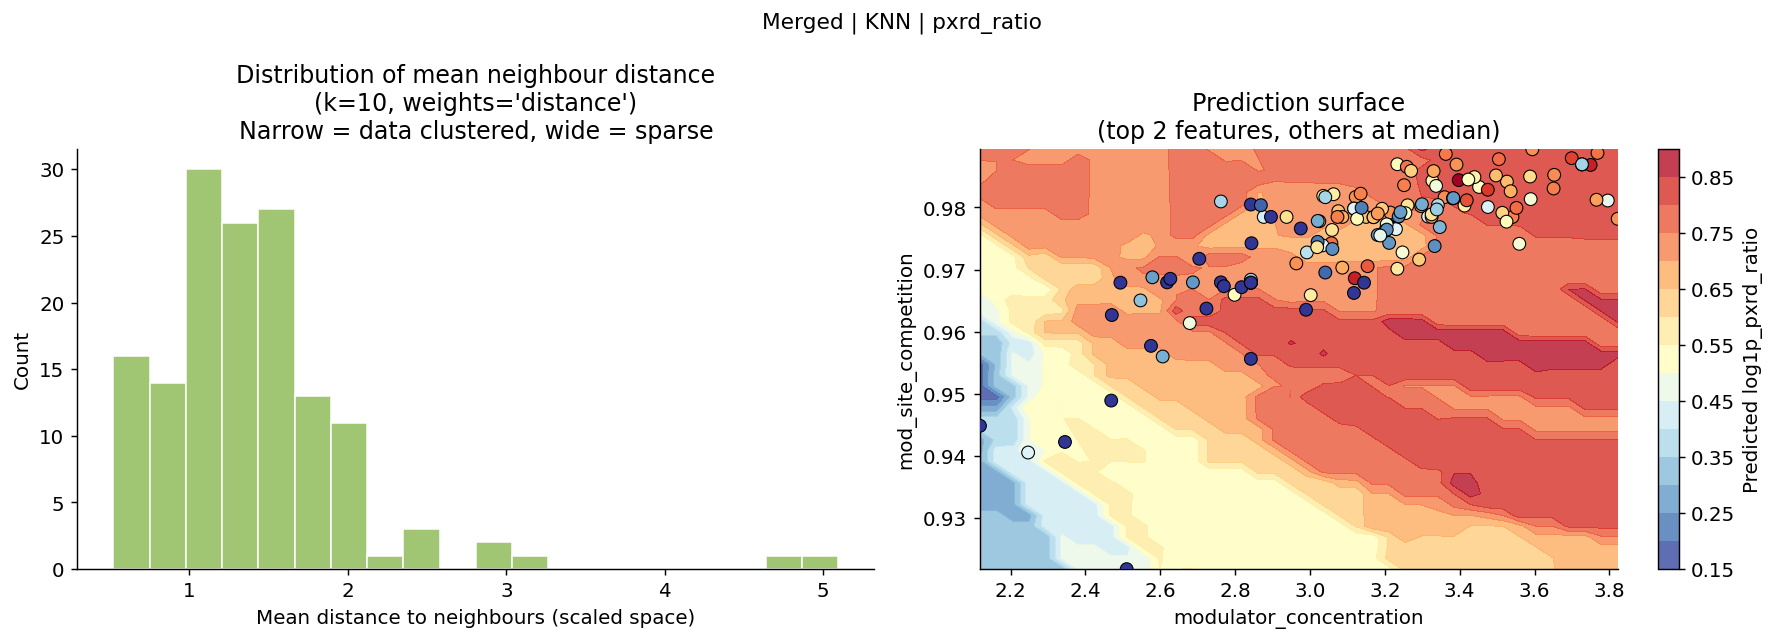

  → KNN: k=10, weights='distance'
  → Top 2 features for surface: modulator_concentration, mod_site_competition


In [ ]:
def plot_model_internals(w, ds_name, target_label):
    entry     = w["entry"]
    model_name = entry["model"]
    pipe      = entry["fitted_pipeline"]
    mdl       = pipe.named_steps["model"]
    sel_feats = w["sel_feats"]
    train_col = w["train_target_col"]
    df_this   = {"BPh": bph, "BA": ba, "Merged": merged}[ds_name]
    color     = PALETTE.get(ds_name, "#888")

    X_df  = df_this[sel_feats].fillna(df_this[sel_feats].median())
    X_sc  = pipe[:-1].transform(X_df)   # imputer + scaler only

    print(f"\n{'═'*65}")
    print(f"  {ds_name} | {model_name} | {target_label}")
    print(f"{'═'*65}")

    # ── ElasticNet / Ridge / Lasso / Linear → Coefficient plot ───────────────
    if hasattr(mdl, "coef_"):
        coefs = np.asarray(mdl.coef_).ravel()   # flatten về 1D
        idx   = np.argsort(np.abs(coefs))[::-1][:15]
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.barh([sel_feats[int(i)] for i in idx[::-1]],
                      coefs[idx[::-1]],
                      color=[color if c >= 0 else "#e05c5c"
                              for c in coefs[idx[::-1]]],
                      alpha=0.85, edgecolor="white")
        ax.axvline(0, color="black", lw=1)
        ax.set_xlabel("Coefficient value (scaled space)")
        ax.set_title(f"{ds_name} | {model_name} | {target_label}\n"
                     f"Coefficients — positive = larger target, negative = smaller")
        for bar, val in zip(bars, coefs[idx[::-1]]):
            ax.text(val + np.sign(val)*0.002, bar.get_y() + bar.get_height()/2,
                    f"{val:+.3f}", va="center", fontsize=8)
        plt.tight_layout()
        fname = f"internals_coef_{ds_name}_{model_name}.png"
        plt.savefig(fname, bbox_inches="tight", dpi=150)
        plt.show()
        print(f"  → ElasticNet/linear: top feature by |coef| = "
              f"{sel_feats[idx[0]]} ({coefs[idx[0]]:+.3f})")

    # ── KNN → K-distance plot + prediction surface (top 2 features) ──────────
    elif hasattr(mdl, "kneighbors"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"{ds_name} | {model_name} | {target_label}", fontsize=12)

        ax = axes[0]
        distances, _ = mdl.kneighbors(X_sc)
        mean_dist = distances.mean(axis=1)
        ax.hist(mean_dist, bins=20, color=color, alpha=0.85, edgecolor="white")
        ax.set_xlabel("Mean distance to neighbours (scaled space)")
        ax.set_ylabel("Count")
        ax.set_title(f"Distribution of mean neighbour distance\n"
                     f"(k={mdl.n_neighbors}, weights='{mdl.weights}')\n"
                     f"Narrow = data clustered, wide = sparse")

        ax = axes[1]
        perm = permutation_importance(pipe, X_df,
                                       df_this[train_col].values,
                                       n_repeats=15, random_state=42)
        top2 = np.argsort(perm.importances_mean)[-2:][::-1]
        f1, f2 = sel_feats[top2[0]], sel_feats[top2[1]]

        grid_x = np.linspace(df_this[f1].min(), df_this[f1].max(), 40)
        grid_y = np.linspace(df_this[f2].min(), df_this[f2].max(), 40)
        xx, yy = np.meshgrid(grid_x, grid_y)

        grid_df = pd.DataFrame(
            np.tile(df_this[sel_feats].median().values, (xx.size, 1)),
            columns=sel_feats)
        grid_df[f1] = xx.ravel()
        grid_df[f2] = yy.ravel()
        zz = pipe.predict(grid_df).reshape(xx.shape)

        cf = ax.contourf(xx, yy, zz, levels=15, cmap="RdYlBu_r", alpha=0.8)
        plt.colorbar(cf, ax=ax, label=f"Predicted {train_col}")
        ax.scatter(df_this[f1], df_this[f2],
                   c=df_this[train_col], cmap="RdYlBu_r",
                   edgecolors="black", s=50, linewidths=0.6, zorder=5)
        ax.set_xlabel(f1); ax.set_ylabel(f2)
        ax.set_title(f"Prediction surface\n(top 2 features, others at median)")

        plt.tight_layout()
        fname = f"internals_knn_{ds_name}_{model_name}.png"
        plt.savefig(fname, bbox_inches="tight", dpi=150)
        plt.show()
        print(f"  → KNN: k={mdl.n_neighbors}, weights='{mdl.weights}'")
        print(f"  → Top 2 features for surface: {f1}, {f2}")

    # ── SVR → Support vectors + margin visualisation ──────────────────────────
    elif hasattr(mdl, "support_vectors_"):
        n_sv   = mdl.support_vectors_.shape[0]
        n_tot  = X_sc.shape[0]
        sv_idx = mdl.support_

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"{ds_name} | {model_name} | {target_label}", fontsize=12)

        ax = axes[0]
        ax.bar(["Support vectors", "Non-support vectors"],
               [n_sv, n_tot - n_sv],
               color=[color, "#cccccc"], alpha=0.85, edgecolor="white")
        ax.set_ylabel("Count")
        ax.set_title(f"Support vectors: {n_sv}/{n_tot} ({n_sv/n_tot:.0%})\n"
                     f"kernel='{mdl.kernel}'  C={mdl.C:.3g}  ε={mdl.epsilon:.3g}")
        for i, v in enumerate([n_sv, n_tot - n_sv]):
            ax.text(i, v + 0.3, str(v), ha="center", fontsize=11)

        ax = axes[1]
        perm = permutation_importance(pipe, X_df,
                                       df_this[train_col].values,
                                       n_repeats=15, random_state=42)
        top2 = np.argsort(perm.importances_mean)[-2:][::-1]
        f1, f2 = sel_feats[top2[0]], sel_feats[top2[1]]

        grid_x = np.linspace(df_this[f1].min(), df_this[f1].max(), 40)
        grid_y = np.linspace(df_this[f2].min(), df_this[f2].max(), 40)
        xx, yy = np.meshgrid(grid_x, grid_y)
        grid_df = pd.DataFrame(
            np.tile(df_this[sel_feats].median().values, (xx.size, 1)),
            columns=sel_feats)
        grid_df[f1] = xx.ravel()
        grid_df[f2] = yy.ravel()
        zz = pipe.predict(grid_df).reshape(xx.shape)

        cf = ax.contourf(xx, yy, zz, levels=15, cmap="RdYlBu_r", alpha=0.8)
        plt.colorbar(cf, ax=ax, label=f"Predicted {train_col}")
        ax.scatter(df_this[f1], df_this[f2],
                   c=df_this[train_col], cmap="RdYlBu_r",
                   edgecolors="black", s=40, linewidths=0.5, zorder=4,
                   label="All points")
        sv_mask = np.zeros(len(df_this), dtype=bool)
        sv_mask[sv_idx] = True
        ax.scatter(df_this[f1].values[sv_mask], df_this[f2].values[sv_mask],
                   facecolors="none", edgecolors="yellow",
                   s=120, linewidths=1.5, zorder=5, label="Support vectors")
        ax.set_xlabel(f1); ax.set_ylabel(f2)
        ax.set_title("Prediction surface + support vectors (yellow)")
        ax.legend(fontsize=8)

        plt.tight_layout()
        fname = f"internals_svr_{ds_name}_{model_name}.png"
        plt.savefig(fname, bbox_inches="tight", dpi=150)
        plt.show()
        print(f"  → SVR: kernel='{mdl.kernel}'  C={mdl.C:.3g}  "
              f"ε={mdl.epsilon:.3g}  n_SV={n_sv}/{n_tot} ({n_sv/n_tot:.0%})")

    # ── KernelRidge → Dual coefficients + kernel similarity ──────────────────
    elif hasattr(mdl, "dual_coef_"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"{ds_name} | {model_name} | {target_label}", fontsize=12)

        ax = axes[0]
        dc = mdl.dual_coef_.ravel()
        ax.bar(range(len(dc)), np.sort(dc)[::-1],
               color=[color if v >= 0 else "#e05c5c" for v in np.sort(dc)[::-1]],
               alpha=0.8, edgecolor="none")
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xlabel("Training point (sorted by dual coef)")
        ax.set_ylabel("Dual coefficient αᵢ")
        ax.set_title(f"Dual coefficients\n"
                     f"Each training point contributes αᵢ × K(xᵢ, x*) to prediction\n"
                     f"Large |αᵢ| = that point is influential")

        ax = axes[1]
        from sklearn.metrics.pairwise import laplacian_kernel, rbf_kernel
        kernel_fn = (laplacian_kernel if "Laplacian" in model_name
                     else rbf_kernel)
        gamma = mdl.gamma if hasattr(mdl, "gamma") else 1.0
        K = kernel_fn(X_sc, gamma=gamma)
        im = ax.imshow(K, cmap="viridis", aspect="auto")
        plt.colorbar(im, ax=ax, label="Kernel similarity K(xᵢ, xⱼ)")
        ax.set_xlabel("Sample index"); ax.set_ylabel("Sample index")
        ax.set_title(f"Kernel similarity matrix\n"
                     f"Bright = similar synthesis conditions\n"
                     f"Dark = dissimilar")

        plt.tight_layout()
        fname = f"internals_kr_{ds_name}_{model_name}.png"
        plt.savefig(fname, bbox_inches="tight", dpi=150)
        plt.show()
        print(f"  → KernelRidge: kernel='{mdl.kernel}'  "
              f"α={mdl.alpha:.3g}  γ={gamma:.3g}")
        print(f"  → n_dual_coef={len(dc)}  "
              f"max|α|={np.abs(dc).max():.3f}  "
              f"influential points: {(np.abs(dc) > np.percentile(np.abs(dc),90)).sum()}")

    else:
        print(f"  → {model_name}: no dedicated internal plot implemented")

# ── Run for all 6 TOP-1 models ─────────────────────────────────────────────────
for (ds, tgt), w in BEST6.items():
    plot_model_internals(w, ds, tgt)


## 17. Fold-Safe (Leak-Corrected) LOO — regime_score / is_likely_large / feature selection

**Why this cell exists.** `regime_score` and `is_likely_large` are built by `find_threshold`,
which searches percentile cut-points to best match `size_regime` — and `size_regime` is a
direct bin of the *actual* continuous target (`particle_size_nm`). In the original runs,
this threshold search (and the Spearman/MI feature-selection step) was fit on the **full**
dataset before LOO started, so every held-out point's own label leaked into the feature
that was later used to predict it.

**What this cell fixes.** For every LOO fold, `regime_score`, `is_likely_large`, feature
selection, and the imputation median are **all recomputed using only the training fold**
(held-out row excluded). The held-out row's own features/label never influence any of
these choices.

**IMPORTANT — this section runs on `BEST6`, not on `WINNERS`.** `BEST6` is the TOP-1
selection actually shipped in the application (Section 11): for five of the six
dataset×target tasks the TOP-1 model comes from the main-notebook run (`source ==
"main_notebook"`), but for **BA / pxrd_ratio** the TOP-1 model is the plain ElasticNet on
6 raw features from Run10_RawTargets (`source == "run10_rawtargets"`, R²=0.556) — not the
23-feature ElasticNet from Run 7 (R²=0.540) that lives in `WINNERS`. Running this section
against `WINNERS` would silently report the leakage/CI numbers for a model that was never
actually deployed. The code below branches on `w["source"]` so every row matches
`Table 12` exactly.

**What this cell does NOT fix (documented, not hidden).** Model hyperparameters are kept
FIXED at the values already tuned on the full dataset in the main run. This is a much
smaller leak than the feature-level one above, and should be named as a residual
limitation.

In [ ]:
from sklearn.base import clone

def find_threshold_train(df_train, feature, positive_class="Large"):
    """Same search as find_threshold(), but computed on df_train ONLY
    (i.e. the held-out LOO row is excluded before the threshold is chosen)."""
    vals = df_train[feature].dropna()
    if len(vals) < 5:
        return float(vals.median()) if len(vals) else 0.0, 0.0
    thresholds = np.percentile(vals, np.arange(10, 91, 5))
    actual = (df_train["size_regime"] == positive_class).astype(int)
    best_t, best_acc = float(vals.median()), 0.0
    for t in thresholds:
        acc = ((df_train[feature] >= t).astype(int) == actual).mean()
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc

def resolve_regime_rules_train(df_train, ds_name):
    """REGIME_RULES thresholds refit on df_train only (BPh or BA subset)."""
    resolved = []
    for feat, thresh in REGIME_RULES[ds_name]:
        if feat not in df_train.columns:
            continue
        if thresh is None:
            thresh, _ = find_threshold_train(df_train, feat)
        resolved.append((feat, thresh))
    return resolved

def regime_score_from_rules(df_rows, rules):
    if not rules:
        return np.zeros(len(df_rows))
    scores = np.zeros(len(df_rows))
    for feat, thresh in rules:
        scores += (df_rows[feat] >= thresh).astype(float)
    return scores / len(rules)

def is_likely_large_threshold_train(df_train, ds_name):
    feat = "modulation_effect" if ds_name == "BPh" else "mod_to_linker"
    thresh, _ = find_threshold_train(df_train, feat)
    return feat, thresh

def select_all_features(df, feature_cols, target_col, dataset_name=None):
    """Identity 'selection' used for the Run10_RawTargets branch: always keep all
    6 raw features exactly as recorded in BEST6[key]['sel_feats']. No leak-prone
    threshold search or correlation-based filtering is involved for this branch —
    Run10_RawTargets never did feature selection in the first place."""
    return list(feature_cols), {}

print("Fold-safe helpers defined (incl. select_all_features for the RawTargets branch).")

Fold-safe helpers defined (incl. select_all_features for the RawTargets branch).


In [ ]:
def nested_safe_loo(df, ds_name, base_feature_cols, target_col,
                     selection_fn, use_regime_score, use_is_likely_large,
                     fixed_estimator, scaler_cls=RobustScaler):
    """
    Fold-safe reproduction of a LOO run:
      - regime_score / is_likely_large thresholds are refit on the TRAINING fold only
      - feature selection (Spearman / union / identity) is refit on the TRAINING fold only
      - median imputation is computed on the TRAINING fold only (not the full df)
      - model hyperparameters are FIXED (cloned from the already-tuned pipeline) —
        NOT re-searched every fold.

    Returns: preds (same transformed space as target_col, same row order as df),
             r2_log, feats_per_fold
    """
    n = len(df)
    idx_all = np.arange(n)
    preds = np.full(n, np.nan)
    feats_per_fold = []

    for i in idx_all:
        train_mask = idx_all != i
        df_train = df.iloc[train_mask].copy()
        df_test  = df.iloc[[i]].copy()

        cols_this = list(base_feature_cols)

        if use_regime_score:
            if ds_name in ("BPh", "BA"):
                rules = resolve_regime_rules_train(df_train, ds_name)
                df_train["regime_score"] = regime_score_from_rules(df_train, rules)
                df_test["regime_score"]  = regime_score_from_rules(df_test, rules)
            else:  # Merged
                df_train["regime_score"] = 0.0
                df_test["regime_score"]  = 0.0
                for sub_ds, mod_flag in [("BPh", "BiPhCOOH"), ("BA", "BA")]:
                    tr_mask = df_train["modulator_type"] == mod_flag
                    sub_train = df_train[tr_mask]
                    if len(sub_train) < 5:
                        continue
                    rules = resolve_regime_rules_train(sub_train, sub_ds)
                    df_train.loc[tr_mask, "regime_score"] = regime_score_from_rules(
                        df_train.loc[tr_mask], rules)
                    if df_test["modulator_type"].iloc[0] == mod_flag:
                        df_test["regime_score"] = regime_score_from_rules(df_test, rules)
            if "regime_score" not in cols_this:
                cols_this = cols_this + ["regime_score"]

        if use_is_likely_large:
            if ds_name in ("BPh", "BA"):
                feat, thresh = is_likely_large_threshold_train(df_train, ds_name)
                df_train["is_likely_large"] = (df_train[feat] >= thresh).astype(int)
                df_test["is_likely_large"]  = (df_test[feat]  >= thresh).astype(int)
            else:  # Merged
                df_train["is_likely_large"] = 0
                df_test["is_likely_large"]  = 0
                for sub_ds, mod_flag in [("BPh", "BiPhCOOH"), ("BA", "BA")]:
                    tr_mask = df_train["modulator_type"] == mod_flag
                    sub_train = df_train[tr_mask]
                    if len(sub_train) < 5:
                        continue
                    feat, thresh = is_likely_large_threshold_train(sub_train, sub_ds)
                    df_train.loc[tr_mask, "is_likely_large"] = (
                        df_train.loc[tr_mask, feat] >= thresh).astype(int)
                    if df_test["modulator_type"].iloc[0] == mod_flag:
                        df_test["is_likely_large"] = (df_test[feat] >= thresh).astype(int)
            if "is_likely_large" not in cols_this:
                cols_this = cols_this + ["is_likely_large"]

        sel_feats, _ = selection_fn(df_train, cols_this, target_col, dataset_name=ds_name)
        feats_per_fold.append(sel_feats)

        med = df_train[sel_feats].median()
        X_train = df_train[sel_feats].fillna(med).values
        y_train = df_train[target_col].values
        X_test  = df_test[sel_feats].fillna(med).values

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  scaler_cls()),
            ("model",   clone(fixed_estimator)),
        ])
        pipe.fit(X_train, y_train)
        preds[i] = pipe.predict(X_test)[0]

    r2_log = r2_score(df[target_col].values, preds)
    return preds, r2_log, feats_per_fold

print("nested_safe_loo defined.")

nested_safe_loo defined.


In [ ]:
# ── Per-key config for the 5 tasks whose BEST6 winner comes from the main notebook.
# (BA/pxrd_ratio is handled separately below because its BEST6 winner is the
#  Run10_RawTargets ElasticNet — see the branch in the loop.)
NESTED_CONFIGS = {
    ("BA", "particle_size_nm"): dict(
        ds="BA", df=ba, base_cols=FEATURE_COLS_R5,
        selection_fn=select_features, use_regime=True, use_ill=False),
    ("BA", "pxrd_ratio"): dict(
        ds="BA", df=ba, base_cols=FEATURE_COLS_R5,
        selection_fn=select_features, use_regime=False, use_ill=True),
    ("BPh", "particle_size_nm"): dict(
        ds="BPh", df=bph, base_cols=FEATURE_COLS_R5,
        selection_fn=select_features_union, use_regime=True, use_ill=False),
    ("BPh", "pxrd_ratio"): dict(
        ds="BPh", df=bph, base_cols=FEATURE_COLS_R2,
        selection_fn=(lambda d, c, t, dataset_name:
                      select_features(d, c, t, threshold=0.3, dataset_name=dataset_name)),
        use_regime=False, use_ill=False),
    ("Merged", "particle_size_nm"): dict(
        ds="Merged", df=merged, base_cols=FEATURE_COLS_R5 + ["modulator_dummy"],
        selection_fn=select_features, use_regime=True, use_ill=False),
    ("Merged", "pxrd_ratio"): dict(
        ds="Merged", df=merged, base_cols=FEATURE_COLS_R5 + ["modulator_dummy"],
        selection_fn=select_features_union, use_regime=True, use_ill=False),
}

RAW_DF = {"BPh": bph, "BA": ba, "Merged": merged}

def back_fn_for(train_target_col):
    if train_target_col == "log10_particle_size":
        return lambda y: 10**y
    elif train_target_col == "log1p_pxrd_ratio":
        return np.expm1
    else:
        return lambda y: y   # Run10_RawTargets v1: already trained directly in original units

nested_results = {}
for key, w in BEST6.items():
    ds, tgt = key
    fixed_est   = clone(w["entry"]["fitted_pipeline"].named_steps["model"])
    target_col  = w["train_target_col"]

    if w["source"] == "main_notebook":
        cfg = NESTED_CONFIGS[key]
        df_use, base_cols   = cfg["df"], cfg["base_cols"]
        selection_fn         = cfg["selection_fn"]
        use_regime, use_ill  = cfg["use_regime"], cfg["use_ill"]
    else:  # "run10_rawtargets" — no engineered/leak-prone feature, no selection at all
        df_use     = RAW_DF[ds]
        base_cols  = list(w["sel_feats"])          # == FEATURE_COLS_RAW (6 features)
        selection_fn = select_all_features
        use_regime, use_ill = False, False

    print(f"\nFold-safe LOO: {ds:<8} {tgt:<20} {w['entry']['model']:<22} [{w['source']}]")
    preds_transformed, r2_transformed_corr, feats_per_fold = nested_safe_loo(
        df_use, ds, base_cols, target_col, selection_fn, use_regime, use_ill,
        fixed_est, scaler_cls=RobustScaler)

    back_fn       = back_fn_for(target_col)
    preds_orig    = back_fn(preds_transformed)
    r2_orig_corr  = r2_score(w["y_true"], preds_orig)
    mae_orig_corr = mean_absolute_error(w["y_true"], preds_orig)
    n_feats_avg   = float(np.mean([len(f) for f in feats_per_fold]))

    nested_results[key] = dict(
        preds_transformed=preds_transformed, r2_transformed=r2_transformed_corr,
        preds_orig=preds_orig, r2_orig=r2_orig_corr, mae_orig=mae_orig_corr,
        n_feats_avg=n_feats_avg, feats_per_fold=feats_per_fold,
    )

    r2_leaky_orig = w["r2_orig"]   # exactly the number reported in Table 12 / BEST6
    print(f"  Leaky      R²(orig)={r2_leaky_orig:+.3f}  [{len(w['sel_feats'])} feats, source={w['source']}]")
    print(f"  Fold-safe  R²(orig)={r2_orig_corr:+.3f}   (avg {n_feats_avg:.1f} features/fold)")


Fold-safe LOO: BA       particle_size_nm     KernelRidge_Laplacian  [main_notebook]
  Leaky      R²(orig)=+0.674  [13 feats, source=main_notebook]
  Fold-safe  R²(orig)=+0.610   (avg 13.0 features/fold)

Fold-safe LOO: BA       pxrd_ratio           ElasticNet             [run10_rawtargets]
  Leaky      R²(orig)=+0.556  [6 feats, source=run10_rawtargets]
  Fold-safe  R²(orig)=+0.556   (avg 6.0 features/fold)

Fold-safe LOO: BPh      particle_size_nm     SVR                    [main_notebook]
  [BPh|log10_particle_size] 21 features (MI-only: ['eq_linker', 'T_reaction', 'linker_conc', 'supersaturation', 'node_linker_coverage', 'delta_T'])
  [BPh|log10_particle_size] 20 features (MI-only: ['eq_linker', 'linker_conc', 'supersaturation', 'node_linker_coverage', 'delta_T'])
  [BPh|log10_particle_size] 21 features (MI-only: ['eq_linker', 'T_reaction', 'linker_conc', 'supersaturation', 'node_linker_coverage', 'delta_T'])
  [BPh|log10_particle_size] 21 features (MI-only: ['eq_linker', 'T_reacti

In [ ]:
rows = []
for key, nr in nested_results.items():
    ds, tgt = key
    w = BEST6[key]
    rows.append({
        "Dataset":                              ds,
        "Target":                                tgt,
        "Source":                                w["source"],
        "Model":                                 w["entry"]["model"],
        "R\u00b2 leaky (orig)":                       round(w["r2_orig"], 3),
        "R\u00b2 fold-safe (orig)":                   round(nr["r2_orig"], 3),
        "\u0394R\u00b2 (leaky \u2212 fold-safe)":               round(w["r2_orig"] - nr["r2_orig"], 3),
        "Avg feats/fold (safe)":                round(nr["n_feats_avg"], 1),
        "Feats (leaky)":                        len(w["sel_feats"]),
    })

df_leak_check = pd.DataFrame(rows).sort_values(
    "\u0394R\u00b2 (leaky \u2212 fold-safe)", ascending=False).reset_index(drop=True)
print(df_leak_check.to_string(index=False))
df_leak_check.to_csv("leakage_correction_comparison.csv", index=False)
print("\nSaved: leakage_correction_comparison.csv  (now consistent with BEST6 / Table 12)")

Dataset           Target           Source                 Model  R² leaky (orig)  R² fold-safe (orig)  ΔR² (leaky − fold-safe)  Avg feats/fold (safe)  Feats (leaky)
     BA particle_size_nm    main_notebook KernelRidge_Laplacian            0.674                0.610                    0.064                   13.0             13
 Merged particle_size_nm    main_notebook                   SVR            0.612                0.597                    0.015                   12.2             12
    BPh       pxrd_ratio    main_notebook                   SVR            0.299                0.290                    0.008                    3.0              3
 Merged       pxrd_ratio    main_notebook                   KNN            0.632                0.624                    0.007                   19.0             19
    BPh particle_size_nm    main_notebook                   SVR            0.507                0.501                    0.006                   20.1             20
     BA   

## 18. Bootstrap 95% Confidence Intervals for R²

**Why.** A point-estimate R² (e.g. 0.674 on n=63) says nothing about how much that number
would move if the experiment were repeated with a different sample of the same size.
With n in the 63–146 range, R² can have wide sampling variance — this needs to be shown,
not just the point estimate, especially for the "flagship" numbers quoted in the Abstract.

**Method — paired bootstrap on LOO predictions (percentile method).**
Since LOO predictions (`y_true`, `y_pred`) are already computed for every winner in
**`BEST6`** (the models actually shipped — see the note in Section 17 about the BA/pxrd_ratio
mismatch with `WINNERS`), no model refitting is needed. For `B=2000` iterations: resample n
indices with replacement from the LOO pairs, compute R² (and MAE) on the resampled pairs,
then take the 2.5th and 97.5th percentiles as the 95% CI.

**Interpretation note.** This CI reflects *sampling uncertainty given the current n and
LOO scheme* — it does NOT correct for the feature-selection/threshold leakage (that's
what Section 17's fold-safe LOO does). Reporting both side by side is the honest picture:
Section 17 shows *how biased* the leaky number was; Section 18 shows *how uncertain*
even an unbiased number would be at this sample size.

In [ ]:
def bootstrap_r2_ci(y_true, y_pred, n_boot=2000, ci=95, random_state=42):
    """Paired percentile bootstrap CI for R² (and MAE) from existing LOO predictions.
    No model refitting — just resamples the (y_true, y_pred) pairs with replacement."""
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true)
    r2_boot  = np.empty(n_boot)
    mae_boot = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, size=n)
        yt, yp = y_true[idx], y_pred[idx]
        if np.allclose(yt, yt[0]):
            r2_boot[b] = np.nan
        else:
            r2_boot[b] = r2_score(yt, yp)
        mae_boot[b] = mean_absolute_error(yt, yp)
    r2_boot = r2_boot[~np.isnan(r2_boot)]
    lo, hi = (100 - ci) / 2, 100 - (100 - ci) / 2
    return {
        "r2_point":   r2_score(y_true, y_pred),
        "r2_ci_lo":   np.percentile(r2_boot, lo),
        "r2_ci_hi":   np.percentile(r2_boot, hi),
        "r2_boot_std": r2_boot.std(),
        "mae_point":  mean_absolute_error(y_true, y_pred),
        "mae_ci_lo":  np.percentile(mae_boot, lo),
        "mae_ci_hi":  np.percentile(mae_boot, hi),
        "n_boot_used": len(r2_boot),
    }

print("bootstrap_r2_ci defined (paired percentile bootstrap, B=2000 default).")

bootstrap_r2_ci defined (paired percentile bootstrap, B=2000 default).


In [ ]:
# ── Bootstrap CI for the 6 DEPLOYED winners (BEST6 — matches Table 12 exactly) ──
rows_ci = []
ci_leaky = {}
for key, w in BEST6.items():
    ds, tgt = key
    res = bootstrap_r2_ci(w["y_true"], w["y_pred"], n_boot=2000, random_state=42)
    ci_leaky[key] = res
    rows_ci.append({
        "Dataset": ds, "Target": tgt, "Source": w["source"],
        "Model": w["entry"]["model"], "Version": "leaky",
        "R2": round(res["r2_point"], 3),
        "95% CI": f"[{res['r2_ci_lo']:.3f}, {res['r2_ci_hi']:.3f}]",
        "CI width": round(res["r2_ci_hi"] - res["r2_ci_lo"], 3),
        "MAE": round(res["mae_point"], 3),
        "MAE 95% CI": f"[{res['mae_ci_lo']:.3f}, {res['mae_ci_hi']:.3f}]",
    })

# ── Same, for the FOLD-SAFE version, only if Section 17 has already been run ──
ci_safe = {}
if "nested_results" in globals():
    for key, nr in nested_results.items():
        ds, tgt = key
        w = BEST6[key]
        res = bootstrap_r2_ci(w["y_true"], nr["preds_orig"], n_boot=2000, random_state=42)
        ci_safe[key] = res
        rows_ci.append({
            "Dataset": ds, "Target": tgt, "Source": w["source"],
            "Model": w["entry"]["model"], "Version": "fold-safe",
            "R2": round(res["r2_point"], 3),
            "95% CI": f"[{res['r2_ci_lo']:.3f}, {res['r2_ci_hi']:.3f}]",
            "CI width": round(res["r2_ci_hi"] - res["r2_ci_lo"], 3),
            "MAE": round(res["mae_point"], 3),
            "MAE 95% CI": f"[{res['mae_ci_lo']:.3f}, {res['mae_ci_hi']:.3f}]",
        })
else:
    print("NOTE: 'nested_results' not found — run Section 17 first if you want the "
          "fold-safe CI rows too. Leaky-version CIs below are computed regardless.")

df_ci = pd.DataFrame(rows_ci).sort_values(["Dataset", "Target", "Version"]).reset_index(drop=True)
print(df_ci.to_string(index=False))
df_ci.to_csv("bootstrap_r2_ci.csv", index=False)
print("\nSaved: bootstrap_r2_ci.csv  (now consistent with BEST6 / Table 12)")

Dataset           Target           Source                 Model   Version    R2         95% CI  CI width     MAE         MAE 95% CI
     BA particle_size_nm    main_notebook KernelRidge_Laplacian fold-safe 0.610 [0.350, 0.769]     0.420 344.701 [227.974, 480.089]
     BA particle_size_nm    main_notebook KernelRidge_Laplacian     leaky 0.674 [0.406, 0.839]     0.433 332.586 [230.304, 458.429]
     BA       pxrd_ratio run10_rawtargets            ElasticNet fold-safe 0.556 [0.391, 0.703]     0.312   0.296     [0.219, 0.390]
     BA       pxrd_ratio run10_rawtargets            ElasticNet     leaky 0.556 [0.391, 0.703]     0.312   0.296     [0.219, 0.390]
    BPh particle_size_nm    main_notebook                   SVR fold-safe 0.501 [0.213, 0.689]     0.476 407.003 [311.631, 508.400]
    BPh particle_size_nm    main_notebook                   SVR     leaky 0.507 [0.229, 0.693]     0.464 405.109 [312.982, 506.841]
    BPh       pxrd_ratio    main_notebook                   SVR fold-safe 0.

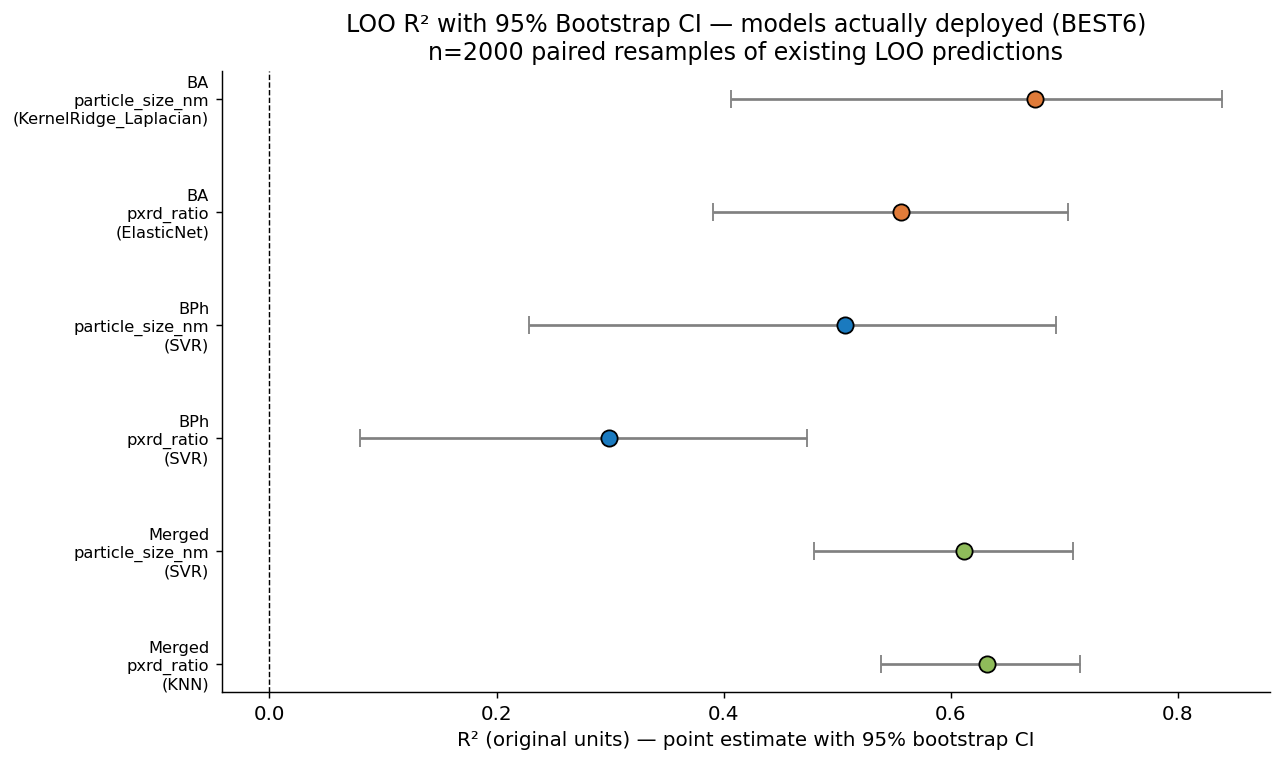

Saved: bootstrap_r2_ci_leaky.png


In [ ]:
# ── Visual: R2 point estimate + 95% CI whiskers, one panel per DEPLOYED winner ──
fig, ax = plt.subplots(figsize=(10, 6))
labels, points, los, his, colors = [], [], [], [], []
for key, w in BEST6.items():
    ds, tgt = key
    res = ci_leaky[key]
    labels.append(f"{ds}\n{tgt}\n({w['entry']['model']})")
    points.append(res["r2_point"]); los.append(res["r2_ci_lo"]); his.append(res["r2_ci_hi"])
    colors.append(PALETTE.get(ds, "#888"))

y_pos = np.arange(len(labels))
# clip at 0: guards against the rare case where the point estimate falls just
# outside its own bootstrap percentile band (can happen for unstable/near-zero R²)
err_lo = np.maximum(np.array(points) - np.array(los), 0)
err_hi = np.maximum(np.array(his) - np.array(points), 0)
ax.errorbar(points, y_pos, xerr=[err_lo, err_hi], fmt="none", capsize=5,
            ecolor="gray", zorder=3)
for i, c in enumerate(colors):
    ax.plot(points[i], y_pos[i], "o", color=c, markersize=9,
            markeredgecolor="black", zorder=4)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("R² (original units) — point estimate with 95% bootstrap CI")
ax.set_title("LOO R² with 95% Bootstrap CI — models actually deployed (BEST6)\n"
             "n=2000 paired resamples of existing LOO predictions")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("bootstrap_r2_ci_leaky.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: bootstrap_r2_ci_leaky.png")